In [1]:
# ─────────────────────────────────────────────────────────────
#  Configuración inicial - Instalación de dependencias
# ─────────────────────────────────────────────────────────────
# !pip install plantuml requests ipython -q

import os
import tempfile
from pathlib import Path
from IPython.display import Image, display, Markdown, Code

# ── Renderizador de diagramas PlantUML ──
try:
    from plantuml import PlantUML
    PLANTUML_SERVER = PlantUML(url='http://www.plantuml.com/plantuml/img/')
    _plantuml_available = True
except ImportError:
    _plantuml_available = False

def render_plantuml(plantuml_code, width=800):
    full_code = plantuml_code.strip()
    if not full_code.startswith('@startuml'):
        full_code = '@startuml\n' + full_code
    if not full_code.rstrip().endswith('@enduml'):
        full_code = full_code.rstrip() + '\n@enduml'

    if _plantuml_available:
        try:
            img_data = PLANTUML_SERVER.processes(full_code)
            display(Image(data=img_data, width=width))
            return
        except Exception:
            pass

    print('[WARN] No se pudo renderizar el diagrama (sin conexion al servidor PlantUML).')
    print('Codigo fuente:')
    print('```plantuml')
    print(full_code)
    print('```')

print('Configuracion completada. Los diagramas PlantUML se renderizaran en linea.')


Configuracion completada. Los diagramas PlantUML se renderizaran en linea.


# 1. ¿Qué es un diagrama de secuencia?

En los bloques anteriores de este curso hemos aprendido a capturar las necesidades funcionales de un sistema mediante casos de uso y a modelar su estructura estática mediante diagramas de clases. Pero entre el *qué* y el *quién* queda un vacío: el *cómo*. ¿Cómo se comunican los objetos entre sí para que un caso de uso se convierta en realidad? ¿En qué orden se pasan los mensajes? ¿Qué objeto asume cada responsabilidad? El diagrama de secuencia es la herramienta UML que responde precisamente a estas preguntas. Es, sin exagerar, el artefacto donde el diseño cobra vida.

## 1.1. Más que flechas y líneas: una coreografía de responsabilidades

En esencia, un diagrama de secuencia es un diagrama de interacción que muestra cómo un conjunto de objetos colaboran para completar un escenario concreto de un caso de uso, representando los mensajes que intercambian en orden cronológico. La palabra *coreografía* no es casual: igual que en un ballet, cada participante (objeto) tiene un rol definido y ejecuta sus movimientos (métodos) en el momento preciso, en respuesta a lo que otros hacen. El diagrama de secuencia captura esa coreografía en una línea temporal que avanza de arriba abajo, transformando una historia de usuario en un diálogo preciso entre instancias de nuestras clases.

El adjetivo *cronológico* es crucial. A diferencia del diagrama de clases, que es atemporal —describe relaciones que existen siempre—, el diagrama de secuencia está anclado en el tiempo. Un mensaje se envía *antes* o *después* que otro; un objeto se crea en un instante y quizás se destruye más tarde. Esa dimensión temporal permite a los desarrolladores entender no solo qué clases intervienen, sino en qué momento y bajo qué condiciones.

Como director de proyecto, siempre insisto en que cada caso de uso relevante tenga al menos un diagrama de secuencia asociado. Mientras que los casos de uso son el contrato con los stakeholders, los diagramas de secuencia son el contrato interno del equipo técnico: definen con precisión quirúrgica cómo se espera que los objetos colaboren, eliminando ambigüedades que de otro modo aflorarían durante la programación.

## 1.2. El diagrama de secuencia como puente entre el análisis y el diseño

Recordemos los tres niveles de abstracción que estamos manejando:

1. **Casos de uso**: el *qué*. Definen las funcionalidades que el sistema ofrece a sus actores, expresadas en lenguaje natural estructurado.
2. **Diagrama de clases**: el *quién*. Modela las clases, sus atributos, sus métodos y sus relaciones permanentes.
3. **Diagrama de secuencia**: el *cómo*. Muestra cómo las instancias de esas clases intercambian mensajes para ejecutar una funcionalidad concreta.

El diagrama de secuencia conecta los otros dos de manera directa y verificable. Cada línea de vida representa una instancia de una clase que *ya existe* en el diagrama de clases. No puede aparecer un objeto que no haya sido declarado previamente en el modelo estructural. Cada mensaje corresponde a un método de la clase receptora, y los parámetros del mensaje deben ser coherentes con los atributos y tipos definidos en dicha clase.

Esta regla de coherencia —que el manual de PlantUML nos permite aplicar con rigor— es una de las disciplinas más saludables que pueden imponerse en un proyecto. Si durante la construcción de un diagrama de secuencia detectamos que necesitamos una clase que no está en el diagrama de clases, no debemos inventarla sobre la marcha; debemos volver al modelo estructural, justificarla desde los casos de uso y añadirla formalmente. Si un mensaje invoca un método que no existe en la clase destino, hay que revisar el diseño: o falta el método en la clase, o la responsabilidad está mal asignada.

## 1.3. Elementos visuales del diagrama de secuencia

Aunque dedicaremos temas completos a cada elemento, conviene presentar aquí un mapa rápido de los componentes que encontraremos en un diagrama de secuencia, tal como los describe la guía de PlantUML (páginas 1 a 44):

- **Líneas de vida (lifelines)**: cada participante —ya sea un actor o una instancia de una clase del modelo— se representa con un rectángulo en la parte superior y una línea vertical discontinua que se extiende hacia abajo. Esa línea es el *eje temporal* del objeto: los mensajes que salen de ella indican que el objeto está activo y enviando una petición; los que llegan, que está recibiendo una solicitud.
- **Mensajes**: flechas que conectan dos líneas de vida. El sentido de la flecha indica quién envía y quién recibe. El tipo de flecha —sólida o punteada, con punta rellena o abierta— comunica si la comunicación es síncrona, asíncrona o de retorno.
- **Activaciones (barras de ejecución)**: rectángulos delgados que aparecen sobre las líneas de vida, indicando el intervalo durante el cual un objeto está ejecutando un método. Son opcionales pero muy útiles para visualizar el flujo de control.
- **Fragmentos combinados**: regiones del diagrama delimitadas por un recuadro con una etiqueta (`alt`, `opt`, `loop`, `par`, `break`, `critical`...). Permiten expresar lógica condicional, bucles, paralelismo y otras estructuras de control directamente en el diagrama, manteniendo la narrativa del caso de uso.
- **Notas y restricciones**: elementos textuales que podemos añadir a cualquier punto del diagrama para aclarar condiciones, precondiciones o detalles de implementación.

En PlantUML, la sintaxis para crear estos elementos es deliberadamente sencilla. Basta con declarar los participantes y escribir los mensajes en orden, de arriba abajo. La herramienta se encarga del resto. Por ejemplo, una interacción simple se define como:


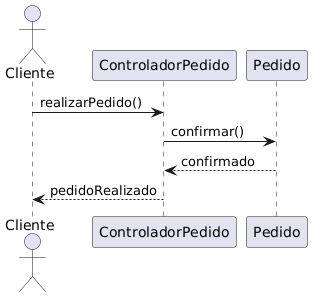

In [2]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor Cliente
participant ControladorPedido
participant Pedido
Cliente -> ControladorPedido: realizarPedido()
ControladorPedido -> Pedido: confirmar()
Pedido --> ControladorPedido: confirmado
ControladorPedido --> Cliente: pedidoRealizado
@enduml'''

render_plantuml(plantuml_code)


La limpieza y legibilidad de esta notación textual es una de las razones por las que PlantUML ha ganado tanto terreno en la documentación de proyectos de software. No se dibuja; se escribe. Y al escribirse, se versiona, se revisa y se mejora como cualquier otro artefacto de código.

## 1.4. El rol de los objetos: derivación estricta desde el diagrama de clases

Aquí debo hacer hincapié en uno de los principios que he impuesto en todos mis equipos y que considero irrenunciable para mantener la integridad del diseño: **toda línea de vida de un diagrama de secuencia que no sea un actor debe corresponder exactamente a una clase definida en el diagrama de clases**. No hay excepciones. No existe un "objeto Sistema" genérico que recibe mensajes como si fuera un monolito. El sistema es más que la suma de sus partes, y el diagrama de secuencia debe mostrar esa colaboración distribuida.

En su lugar, el diagrama de secuencia se puebla con instancias de las clases que ya hemos modelado: objetos de frontera (`<<boundary>>`) que gestionan la interacción con el usuario; objetos de control (`<<control>>`) que orquestan la lógica del caso de uso; objetos de entidad (`<<entity>>`) que representan los datos del dominio; y servicios externos o de infraestructura que también deben estar representados en el modelo de clases.

Si en el diagrama de clases tenemos `ControladorPedido`, `Pedido`, `Producto`, `Cliente` y `ServicioPago`, esas son las piezas que aparecerán en el diagrama de secuencia de "Realizar Pedido". Ninguna más, ninguna menos. Si durante la elaboración del diagrama de secuencia surge la necesidad de una nueva clase, se vuelve al diagrama de clases, se analiza su pertinencia en el contexto de los casos de uso y, si procede, se añade formalmente. Este ir y venir entre el modelo estático y el dinámico es lo que garantiza la coherencia global del diseño.

## 1.5. Derivación del comportamiento desde los casos de uso

Así como los objetos provienen del diagrama de clases, los mensajes y la lógica de interacción provienen directamente de los casos de uso. Cada paso de la especificación textual —tanto del flujo básico como de los flujos alternativos y de excepción— se traduce en uno o varios mensajes entre los objetos participantes.

Para el caso de uso "Realizar Pedido", cuyo flujo básico ya conocemos, el primer paso ("El Cliente solicita iniciar un nuevo pedido") podría traducirse en un mensaje del actor `Cliente` a un objeto de interfaz `FormularioPedido` (una clase `<<boundary>>`). El paso "El Sistema agrega los productos al carrito" podría descomponerse en mensajes entre un `ControladorPedido`, un `Carrito` y varios `Producto`. Cada acción del sistema es una colaboración entre objetos, y esa colaboración es precisamente lo que el diagrama de secuencia documenta.

Lo crucial es que no hay invención libre: el diagrama de secuencia debe poder leerse junto a la especificación del caso de uso y comprobarse que cada paso está cubierto por la interacción modelada. Esta trazabilidad es la que me permite, como director de proyecto, revisar un diagrama de secuencia y saber exactamente qué funcionalidad está implementando, y también detectar si falta algo o si se ha añadido complejidad injustificada.

## 1.6. Un ejemplo integrador: el flujo básico de "Realizar Pedido"

Para anclar estos conceptos, imaginemos visualmente cómo se vería un fragmento del diagrama de secuencia para nuestro caso de uso de referencia. No vamos a construirlo completo aún —eso será parte de los temas siguientes—, pero sí esbozar su estructura:

1. El actor `Cliente` inicia la interacción enviando un mensaje a un formulario de pedido.
2. El formulario solicita a un controlador que gestione la operación.
3. El controlador verifica el stock mediante una consulta a objetos `Producto`, añade las líneas de pedido al objeto `Pedido`, y cuando todo está listo, invoca al `ServicioPago` para que procese la transacción.
4. Si el pago es exitoso, el controlador solicita al `ServicioCorreo` el envío de la confirmación.
5. Finalmente, el controlador retorna al formulario, que muestra el resultado al actor.

En este esbozo, todos los objetos (`FormularioPedido`, `ControladorPedido`, `Producto`, `Pedido`, `ServicioPago`, `ServicioCorreo`) existen previamente en el diagrama de clases. Todos los mensajes (`verificarStock()`, `agregarLinea()`, `procesarPago()`, `enviarConfirmacion()`) corresponden a métodos definidos en esas clases. Y la secuencia de mensajes sigue, punto por punto, el flujo básico del caso de uso. Este es el nivel de coherencia que debemos exigir a nuestros modelos.

## 1.7. Más allá del escenario único: una red de diagramas

Un solo diagrama de secuencia no captura toda la complejidad de un caso de uso. Normalmente se elaboran varios:

- Un diagrama para el **flujo básico** (happy path).
- Diagramas adicionales para cada **flujo alternativo** que tenga suficiente entidad (por ejemplo, "Pago con PayPal").
- Diagramas para los **flujos de excepción** más críticos (por ejemplo, "Producto sin stock" o "Pago rechazado").

Esta familia de diagramas funciona como un todo: el diagrama de clases sigue siendo único (es la unión de todos los objetos que aparecen en los distintos diagramas de secuencia), pero cada escenario de interacción se documenta por separado, manteniendo la claridad de cada uno.

PlantUML facilita esta práctica porque podemos tener un archivo `.puml` por escenario, todos ellos incluyendo el mismo modelo de clases mediante `!include`, garantizando que los objetos sean consistentes.

Con esto concluye la introducción al diagrama de secuencia. En los siguientes temas, profundizaremos en cada uno de sus elementos —líneas de vida, mensajes, activaciones, fragmentos combinados— y aprenderemos a construirlo sistemáticamente a partir del diagrama de clases y los casos de uso. Pero la idea fundamental ya está sembrada: el diagrama de secuencia es la coreografía que demuestra que nuestro diseño estático es capaz de ejecutar las historias que prometimos a los actores. Y como toda buena coreografía, requiere disciplina, precisión y ensayo constante.

# 2. Elementos fundamentales del diagrama de secuencia

En el tema anterior, establecimos que el diagrama de secuencia es la coreografía que demuestra cómo nuestros objetos —esos que definimos cuidadosamente en el diagrama de clases— colaboran para materializar un caso de uso. Ahora es el momento de bajar al detalle y diseccionar cada uno de los ladrillos con los que se construye esa coreografía. Conocer estos elementos no solo nos permitirá leer cualquier diagrama de secuencia que encontremos, sino también escribirlos con la precisión que PlantUML exige y que el equipo de desarrollo merece.

La guía de referencia de PlantUML que manejamos (páginas 1 a 44) dedica una atención meticulosa a estos componentes, proporcionando una sintaxis que, aunque sencilla en apariencia, esconde una gran expresividad. Vamos a explorar los cuatro pilares del diagrama de secuencia: las líneas de vida, los mensajes, las activaciones y los fragmentos combinados. En cada caso, mostraremos cómo la notación UML se traduce a código PlantUML, siempre con la vista puesta en que estos elementos deben ser un reflejo fiel de nuestras clases y nuestros casos de uso.

## 2.1. Líneas de vida: los participantes en escena

Una línea de vida representa la existencia de un participante durante el período que abarca el diagrama. Ese participante puede ser un **actor** (externo al sistema, como el Cliente) o una **instancia de una clase** extraída del diagrama de clases. Como ya hemos insistido, cada línea de vida que no sea un actor debe corresponderse con una clase concreta de nuestro modelo estructural: `Pedido`, `Cliente`, `ControladorPedido`, `ServicioCorreo`, etc. No hay espacio para participantes anónimos ni para un omnipresente "Sistema".

En UML, la línea de vida se dibuja como un rectángulo en la cabecera (que contiene el nombre del participante, a menudo en el formato `nombreInstancia: NombreClase`) y una línea vertical discontinua que desciende por el diagrama. Esa línea vertical es la "línea de vida" propiamente dicha: el eje temporal sobre el que se suceden los mensajes que envía o recibe el participante.

PlantUML nos ofrece varias formas de declarar participantes, y la elección de una u otra no es trivial, porque cada una comunica un rol distinto en el sistema. La guía del lenguaje (páginas 2-4) distingue las siguientes palabras clave para declarar líneas de vida:

- `actor`: representa un actor humano o un sistema externo. Visualmente, se dibuja con el icono del monigote (o la figura estilizada según el `skinparam` elegido). Es el punto de partida habitual de la interacción.
- `boundary`: un objeto de frontera, típicamente una interfaz de usuario o una API. Suele ser el primer objeto que recibe el mensaje del actor y el último en devolverle la respuesta.
- `control`: un objeto de control, que orquesta la lógica del caso de uso. Coordina a otros objetos, toma decisiones basadas en la lógica de negocio y delega en entidades y servicios.
- `entity`: un objeto de entidad, que representa datos persistentes del dominio.
- `database`: una base de datos, a menudo externa al sistema pero que puede modelarse como participante si el diagrama de secuencia necesita mostrar interacciones con ella.
- `collections`: una colección de objetos.
- `participant`: genérico, si no queremos especificar un rol concreto. Se puede usar para cualquier clase.

Todas estas palabras clave pueden ir seguidas del nombre del participante (entre comillas si contiene espacios o caracteres especiales) y de un alias con `as` para simplificar los mensajes posteriores. También es posible cambiar el color de fondo con `#color` y añadir estereotipos con `<< >>`. La guía incluso permite declarar participantes en varias líneas usando `participant MultiLine`.

Veamos un ejemplo de declaración de participantes para el caso de uso "Realizar Pedido", alineado con nuestro diagrama de clases:


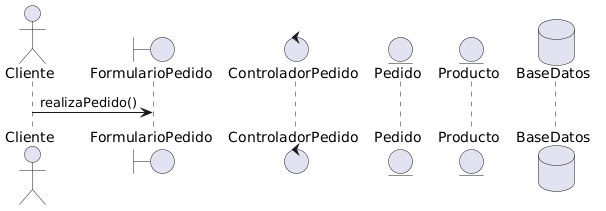

In [3]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor "Cliente" as Cl
boundary "FormularioPedido" as FP
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod
database "BaseDatos" as BD
Cl -> FP: realizaPedido()
@enduml'''

render_plantuml(plantuml_code)


Cada uno de estos participantes existe en el diagrama de clases: `FormularioPedido` es una clase `<<boundary>>`, `ControladorPedido` es `<<control>>`, `Pedido` y `Producto` son `<<entity>>`. La coherencia es total.

## 2.2. Mensajes: el diálogo entre objetos

Los mensajes son las flechas que conectan las líneas de vida y que transportan información o solicitudes. Cada mensaje representa la invocación de un método de la clase que recibe el mensaje, o al menos una señal que el objeto receptor debe interpretar. En un diagrama de secuencia bien construido, cada mensaje debería poder mapearse a un método concreto de la clase destino en el diagrama de clases.

UML distingue varios tipos de mensajes, y PlantUML ofrece una notación específica para cada uno:

### 2.2.1. Mensaje síncrono (o de llamada)

Es el más común. El emisor envía el mensaje y **se queda esperando** hasta que el receptor procesa la petición y devuelve el control (normalmente con un mensaje de retorno). En UML se dibuja con una línea continua y una punta de flecha **rellena** (triángulo negro). En PlantUML, se consigue con la flecha `->` estándar.


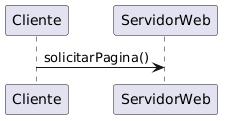

In [4]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cliente -> ServidorWeb: solicitarPagina()
@enduml'''

render_plantuml(plantuml_code)


También podemos usar `-->` para obtener un trazo discontinuo con punta de flecha normal, si queremos transmitir un matiz menos intenso, aunque la semántica síncrona se suele asociar al trazo sólido.

### 2.2.2. Mensaje asíncrono

El emisor envía el mensaje y **continúa su ejecución inmediatamente**, sin esperar respuesta. Es típico en sistemas basados en eventos, mensajería o notificaciones. Se dibuja con una línea continua y una punta de flecha **abierta** (solo los dos trazos laterales). En PlantUML, se logra con la flecha `->>` o `-->` si el trazo es discontinuo.


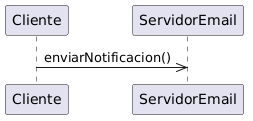

In [5]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cliente ->> ServidorEmail: enviarNotificacion()
@enduml'''

render_plantuml(plantuml_code)


La diferencia entre síncrono y asíncrono tiene implicaciones directas en el código: una llamada síncrona bloqueará el hilo de ejecución; una asíncrona probablemente se implementará con una cola de mensajes, un callback o una operación "fire and forget".

### 2.2.3. Mensaje de retorno

Representa el retorno desde una llamada síncrona. Puede llevar un valor de vuelta o simplemente indicar que el control regresa al emisor. En UML se dibuja con una línea **discontinua** y una punta de flecha abierta. En PlantUML, se obtiene con `-->`.


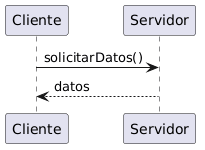

In [6]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cliente -> Servidor: solicitarDatos()
Servidor --> Cliente: datos
@enduml'''

render_plantuml(plantuml_code)


Los retornos son opcionales y, en muchos diagramas, se omiten para no recargar el dibujo cuando el valor de retorno no es relevante. Sin embargo, en fases de diseño detallado, pueden ser muy útiles para especificar qué datos viajan de vuelta.

### 2.2.4. Creación y destrucción de objetos

En ciertos escenarios, necesitamos mostrar que un objeto se crea en medio de la interacción o que es destruido al final de ella. PlantUML ofrece la palabra reservada `create` antes del mensaje que provoca la creación, y `destroy` para marcar el fin de la línea de vida.


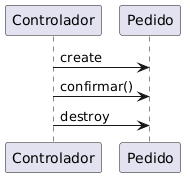

In [7]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Controlador -> Pedido: create
Controlador -> Pedido: confirmar()
Controlador -> Pedido: destroy
@enduml'''

render_plantuml(plantuml_code)


La guía (páginas 21-23) también presenta una sintaxis abreviada muy elegante: `++` para activar y crear, `--` para desactivar, `**` para crear una instancia y `!!` para destruirla. Esta notación compacta simplifica el código PlantUML y mantiene el diagrama limpio.

### 2.2.5. Flechas de entrada y salida

Cuando queremos centrar la atención en una parte del diagrama y no nos interesa detallar quién está fuera, o cuando el diagrama está incompleto, PlantUML permite usar corchetes `[` y `]` para indicar flechas entrantes o salientes de participantes no especificados (página 23). Sin embargo, en el espíritu de rigor que estamos cultivando, solo deberíamos usar estas notaciones en contextos muy controlados donde el participante externo esté claramente identificado, por ejemplo, como un actor externo que ya aparece en el diagrama.

En resumen, la elección del tipo de flecha comunica mucho más que un simple sentido de comunicación; expresa el protocolo de interacción entre objetos, y condiciona cómo se escribirá el código. Al traducir los pasos del caso de uso a mensajes, debemos preguntarnos: ¿esta interacción es una llamada bloqueante? ¿Es una notificación que no espera respuesta? La respuesta determinará la flecha correcta.

## 2.3. Activaciones: el foco de la ejecución

Una activación (también llamada *foco de control* o *barra de activación*) es un rectángulo fino que se superpone a la línea de vida de un objeto y que indica el período durante el cual ese objeto está ejecutando un método. Comienza cuando el objeto recibe un mensaje y termina cuando el objeto devuelve el control (o cuando finaliza el método sin retorno). Visualmente, las activaciones transforman las líneas de vida pasivas en actores activos, y muestran con claridad la profundidad de las llamadas anidadas.

PlantUML puede dibujar activaciones automáticamente cuando usamos las flechas `->` y `-->`, pero también permite un control explícito con los comandos `activate` y `deactivate` aplicados al participante (página 19). Además, la sintaxis abreviada que mencioné antes —`++` para activar, `--` para desactivar— es aún más compacta y recomendable.


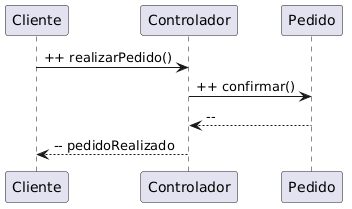

In [8]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cliente -> Controlador: ++ realizarPedido()
Controlador -> Pedido: ++ confirmar()
Pedido --> Controlador: --
Controlador --> Cliente: -- pedidoRealizado
@enduml'''

render_plantuml(plantuml_code)


En este ejemplo, `++` después del mensaje activa al objeto receptor (y desactiva al emisor si no sigue activo), mientras que `--` en el mensaje de retorno desactiva al objeto que responde. El resultado visual es un diagrama con barras de activación bien delimitadas, que cualquier desarrollador puede interpretar de un vistazo.

Las activaciones son especialmente valiosas cuando hay llamadas anidadas profundas, porque muestran gráficamente la pila de ejecución. Si un controlador llama a un servicio, que a su vez consulta una base de datos, las activaciones formarán un perfil escalonado que revela la estructura del flujo de control.

## 2.4. Fragmentos combinados: cuando el flujo no es lineal

Hasta ahora, hemos modelado secuencias lineales de mensajes. Pero los casos de uso raramente son lineales: contienen condiciones, bucles, opciones y paralelismo. UML introdujo los **fragmentos combinados** para manejar estas situaciones, y PlantUML los soporta completamente mediante las palabras reservadas que la guía detalla en las páginas 10-12.

Un fragmento combinado es un área del diagrama delimitada por un rectángulo (a veces con una etiqueta) que agrupa una parte de la interacción y la somete a una regla de control. Los más comunes son:

- **`alt`**: condición múltiple (if/else). Divide el fragmento en varias regiones (separadas por `else`) y solo se ejecuta la que cumple la condición. Ideal para modelar flujos alternativos o de excepción.
- **`opt`**: condición opcional. Se ejecuta solo si se cumple la guarda. Equivale a un `if` sin `else`.
- **`loop`**: repetición. El fragmento se repite mientras la condición sea verdadera o un número fijo de veces. Imprescindible para modelar iteraciones como "para cada producto en el carrito".
- **`par`**: ejecución en paralelo. Los mensajes de las distintas regiones del fragmento se ejecutan concurrentemente.
- **`break`**: interrupción. Si la condición se cumple, se ejecuta el fragmento y luego se abandona la interacción principal (como un `break` en un bucle).
- **`critical`**: región crítica. Las interrupciones no pueden ocurrir dentro de esta región.
- **`group`**: agrupación genérica con etiqueta personalizada para documentar.

PlantUML emplea una sintaxis muy natural para estos fragmentos:


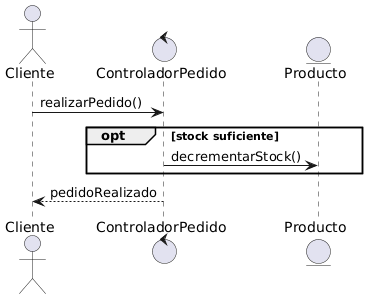

In [9]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor Cliente
control ControladorPedido as CP
entity Producto
Cliente -> CP: realizarPedido()
opt stock suficiente
  CP -> Producto: decrementarStock()
end
CP --> Cliente: pedidoRealizado
@enduml'''

render_plantuml(plantuml_code)


En este ejemplo, el fragmento `opt` condiciona la ejecución del mensaje `decrementarStock()` a que se cumpla la guarda "stock suficiente". La sintaxis es la misma para `alt` con `else`, `loop` con condición de repetición, etc.

Los fragmentos combinados no son opcionales cuando el caso de uso que estamos modelando contiene bifurcaciones. De hecho, deberían ser un calco de la estructura de la especificación textual: si el flujo básico dice "si el producto está agotado, notificar al cliente", en el diagrama de secuencia aparecerá un fragmento `alt` que modele ese camino. La correspondencia entre el texto y el gráfico debe ser tan directa que un tester pueda leer ambos y validar que el diagrama cubre todos los escenarios.

## 2.5. Integrando los elementos: un ejemplo comentado

Antes de cerrar este tema, quiero mostrar cómo estos cuatro elementos —líneas de vida, mensajes, activaciones y fragmentos combinados— se ensamblan en un diagrama coherente. Tomemos un fragmento mínimo del flujo básico de "Realizar Pedido": el cliente añade un producto al carrito. Los participantes son `Cliente` (actor), `FormularioPedido` (`<<boundary>>`), `ControladorPedido` (`<<control>>`) y `Producto` (`<<entity>>`), todos de nuestro modelo de clases.


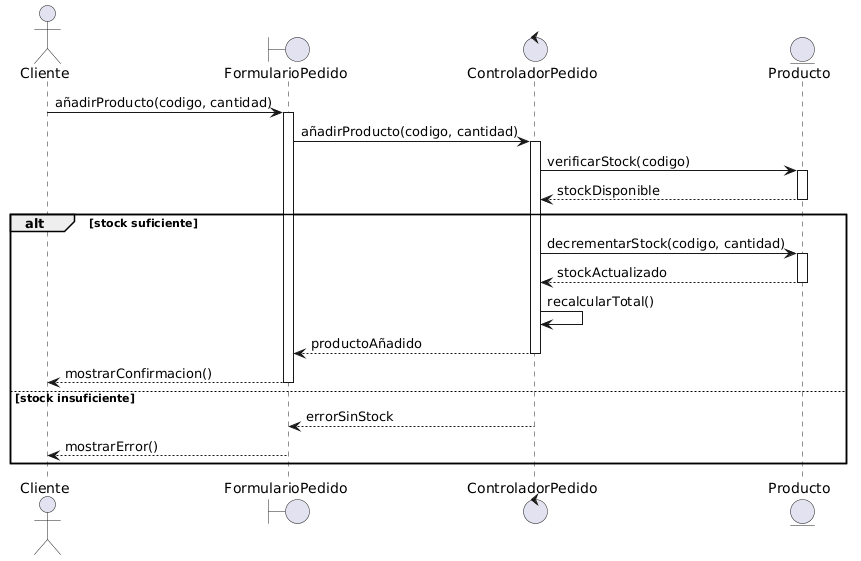

In [10]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor Cliente as Cl
boundary FormularioPedido as FP
control ControladorPedido as CP
entity Producto as Prod

Cl -> FP: añadirProducto(codigo, cantidad)
activate FP
FP -> CP: añadirProducto(codigo, cantidad)
activate CP
CP -> Prod: verificarStock(codigo)
activate Prod
Prod --> CP: stockDisponible
deactivate Prod
alt stock suficiente
  CP -> Prod: decrementarStock(codigo, cantidad)
  activate Prod
  Prod --> CP: stockActualizado
  deactivate Prod
  CP -> CP: recalcularTotal()
  CP --> FP: productoAñadido
  deactivate CP
  FP --> Cl: mostrarConfirmacion()
  deactivate FP
else stock insuficiente
  CP --> FP: errorSinStock
  deactivate CP
  FP --> Cl: mostrarError()
  deactivate FP
end
@enduml'''

render_plantuml(plantuml_code)


Analicemos el diagrama:

- Las **líneas de vida** están declaradas al inicio y cada una tiene un alias. Corresponden a clases de nuestro modelo.
- Los **mensajes** fluyen de arriba abajo, con llamadas síncronas (`->`) y retornos (`-->`). Los nombres de los mensajes se asemejan a métodos de las clases involucradas.
- Las **activaciones** (gestionadas con `activate`/`deactivate`) muestran claramente quién está ejecutando código en cada momento.
- El **fragmento combinado `alt`** modela la condición de stock suficiente o insuficiente, que es un flujo alternativo del caso de uso.

Este diagrama podría ser leído por cualquier desarrollador, que sabría exactamente qué métodos implementar y cómo deben interactuar las clases. Y cualquier tester podría derivar de aquí escenarios de prueba positivos y negativos.

## 2.6. Buenas prácticas en el uso de los elementos fundamentales

Para que estos elementos no se conviertan en un fin en sí mismos, sino en herramientas al servicio del diseño, conviene seguir algunas pautas:

- **Nombres de mensajes coherentes con los métodos del diagrama de clases**: si en el diagrama de secuencia se envía `verificarStock()`, en la clase `Producto` debe existir ese método. No inventar nombres de mensajes que luego no tengan reflejo en el código.
- **No abusar de las líneas de vida**: incluir solo los objetos estrictamente necesarios para el escenario. Si un diagrama tiene más de seis o siete participantes, quizás sea necesario dividir el escenario en sub-interacciones.
- **Mostrar activaciones solo cuando aporten claridad**: en secuencias muy cortas, las activaciones pueden omitirse. En secuencias con llamadas anidadas, son casi imprescindibles.
- **Nombrar los fragmentos combinados con guardas que parafraseen la especificación textual**: "stock suficiente", "cliente autenticado", "pago aceptado". Así se mantiene la trazabilidad con el caso de uso.
- **Evitar anidar fragmentos combinados más de dos o tres niveles**: si la lógica es tan compleja, conviene extraer parte de la interacción a otro diagrama de secuencia referenciado con `ref`.

En el próximo tema, abordaremos precisamente la **derivación estricta de los objetos desde el diagrama de clases**, profundizando en por qué no debe existir un "objeto Sistema" y cómo cada participante del diagrama de secuencia debe tener un origen claro en el modelo estructural. Este será el puente definitivo entre la vista estática y la dinámica del sistema.

# 3. Derivación estricta de los objetos desde el diagrama de clases

Llegamos al que, en mi opinión, es el tema más disciplinante de todo el modelado dinámico. Hemos visto qué es un diagrama de secuencia y qué elementos lo componen. Ahora vamos a establecer el cordón umbilical que une este diagrama con el modelo estructural que construimos previamente. Porque un diagrama de secuencia no es un dibujo libre; es una proyección dinámica del diagrama de clases. Y esa proyección debe ser rigurosa, verificable y exenta de invenciones.

## 3.1. La regla fundamental: cada línea de vida, una clase del modelo estructural

En todos los proyectos que he dirigido, impongo una norma que considero irrenunciable: **toda línea de vida que aparezca en un diagrama de secuencia, salvo los actores, debe corresponder exactamente a una clase definida en el diagrama de clases del sistema.** No hay excepciones. No hay atajos. No hay objetos que surjan por conveniencia narrativa sin tener un anclaje en la estructura estática del software.

Esta regla tiene una justificación profunda. El diagrama de clases es nuestro contrato estructural: define qué piezas componen el sistema, qué datos almacenan y qué operaciones pueden realizar. Si el diagrama de secuencia introdujese objetos no declarados, estaríamos modelando un comportamiento que no se sustenta en ninguna estructura. Sería como describir el movimiento de un edificio sin haber definido sus pilares. Tarde o temprano, esa incoherencia se pagaría con código inconsistente, pruebas que no saben contra qué contrastar y una documentación que nadie usa porque ha perdido la credibilidad.

Veamos un ejemplo concreto. Supongamos que en el diagrama de clases de nuestro sistema de comercio electrónico hemos definido las siguientes clases:

- `Cliente` (entidad)
- `Pedido` (entidad)
- `LineaPedido` (entidad)
- `Producto` (entidad)
- `Carrito` (control)
- `ControladorPedido` (control)
- `Catalogo` (frontera)
- `FormularioPedido` (frontera)
- `ServicioPago` (servicio)
- `ServicioCorreo` (servicio)

Pues bien, cualquier diagrama de secuencia que modele un escenario de "Realizar Pedido" debe emplear **exclusivamente** instancias de estas clases (más el actor `Cliente`). Si durante la elaboración del diagrama de secuencia siento la necesidad de introducir una nueva clase —por ejemplo, un `ValidadorDireccion` que no había previsto— no debo añadirla directamente al diagrama de secuencia ignorando el modelo de clases. Debo detenerme, volver al diagrama de clases, analizar si esa clase está justificada por los casos de uso, añadirla formalmente con sus atributos, métodos y relaciones, y solo entonces incorporarla al diagrama de secuencia.

Este ir y venir entre la vista dinámica y la estática es, precisamente, el latido del diseño orientado a objetos. El diagrama de secuencia se convierte así en una herramienta de validación del modelo de clases: si descubro que necesito una clase que no existe, el modelo estructural estaba incompleto. Si, por el contrario, tengo clases en el diagrama estático que nunca aparecen en ningún diagrama de secuencia, quizás esas clases son innecesarias y deberían eliminarse. La simbiosis es perfecta.

## 3.2. La falacia del "objeto Sistema" y su descomposición

Uno de los vicios más arraigados que he tenido que combatir en ingenieros novatos —y en algunos no tan novatos— es la tendencia a modelar un único participante llamado "Sistema" que recibe todos los mensajes del actor y, mágicamente, resuelve el caso de uso. Ese "Sistema" es una caja negra que lo hace todo, y el diagrama de secuencia se reduce a un diálogo estéril entre un actor y un monolito.

Esto es un error grave por varias razones:

- Viola el principio de responsabilidad única: un solo objeto no puede ser responsable de la interfaz de usuario, la lógica de negocio, la persistencia y la comunicación con servicios externos.
- Oculta la complejidad real del diseño: al no mostrar los objetos que colaboran, el diagrama no comunica nada útil al desarrollador, que tendrá que adivinar por su cuenta cómo implementar la funcionalidad.
- Impide la trazabilidad con el modelo de clases: si todo lo hace un "Sistema" genérico, ¿dónde están las clases que definimos? ¿Para qué sirven entonces?

La alternativa correcta es descomponer el "Sistema" en los objetos que realmente lo constituyen, utilizando los roles que UML y PlantUML nos ofrecen para clasificarlos:

- **Objetos de frontera** (`<<boundary>>`): gestionan la interacción con el actor. Son las pantallas, formularios, APIs REST, interfaces de línea de comandos... todo aquello que traduce las acciones del actor en mensajes hacia el interior del sistema, y las respuestas del sistema en información legible para el actor. En PlantUML, se declaran con la palabra reservada `boundary`. En nuestro ejemplo, `FormularioPedido` y `Catalogo` pertenecen a esta categoría.

- **Objetos de control** (`<<control>>`): coordinan la lógica del caso de uso. No almacenan datos persistentes ni interactúan directamente con el actor; su misión es orquestar la colaboración entre los objetos de frontera, las entidades y los servicios. En PlantUML, se declaran con `control`. Nuestro `ControladorPedido` y `Carrito` son ejemplos típicos.

- **Objetos de entidad** (`<<entity>>`): representan los datos del dominio que persisten más allá de la ejecución del caso de uso. Suelen mapearse a tablas de base de datos. `Pedido`, `Producto`, `LineaPedido` y `Cliente` son entidades.

- **Servicios y recursos externos**: aunque no tienen una palabra clave dedicada en PlantUML (se suelen declarar como `participant` o con la palabra que corresponda, como `database`), estas clases representan sistemas externos o subsistemas de infraestructura (`ServicioPago`, `ServicioCorreo`). Si son externos al sistema que estamos construyendo, pueden modelarse como actores secundarios; si son clases internas de infraestructura, deben figurar en el diagrama de clases como tales.

La guía de PlantUML (páginas 3-4) nos proporciona precisamente estas palabras clave para declarar participantes, y es nuestra responsabilidad como diseñadores usarlas con propiedad. Cada `boundary`, `control`, `entity` o `database` que aparezca en un diagrama de secuencia debe tener su correspondiente clase en el modelo estructural, estereotipada adecuadamente.

Un diagrama de secuencia correctamente descompuesto para "Realizar Pedido" podría arrancar así:


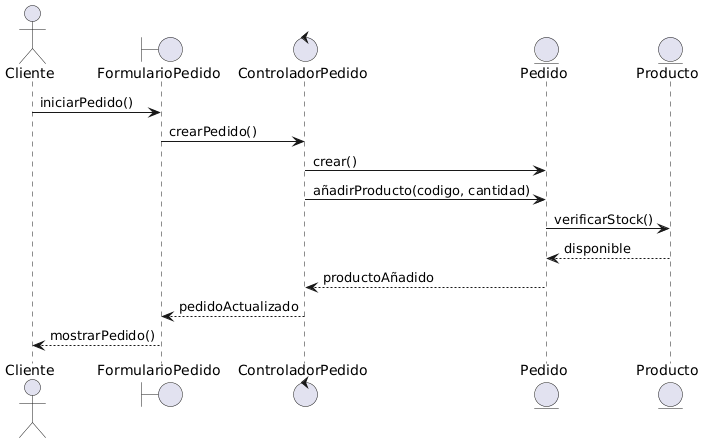

In [11]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor "Cliente" as Cl
boundary "FormularioPedido" as FP
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod
Cl -> FP: iniciarPedido()
FP -> CP: crearPedido()
CP -> Ped: crear()
CP -> Ped: añadirProducto(codigo, cantidad)
Ped -> Prod: verificarStock()
Prod --> Ped: disponible
Ped --> CP: productoAñadido
CP --> FP: pedidoActualizado
FP --> Cl: mostrarPedido()
@enduml'''

render_plantuml(plantuml_code)


Observen cómo la interacción se distribuye entre varios objetos, cada uno con una responsabilidad clara. `FormularioPedido` solo dialoga con el actor y con el controlador. `ControladorPedido` coordina la creación del pedido y la adición de productos. `Pedido` se encarga de su propia lógica (añadir productos) y delega en `Producto` la verificación de stock. No hay un "Sistema" omnisciente; hay una coreografía de objetos que colaboran.

## 3.3. Coherencia de métodos y atributos con el modelo estructural

La derivación estricta no se limita a la existencia de las clases. Los **mensajes** que intercambian los objetos en el diagrama de secuencia deben corresponderse con **métodos** reales de las clases receptoras en el diagrama de clases. Si en el diagrama de secuencia escribo `Ped -> Prod: verificarStock()`, en la clase `Producto` del diagrama de clases debe existir un método `verificarStock()` (con los parámetros que correspondan y el tipo de retorno adecuado). Si envío `CP -> Ped: añadirProducto(codigo, cantidad)`, la clase `Pedido` debe declarar ese método.

De igual modo, los **atributos** que viajan como parámetros en los mensajes o que se mencionan en las notas del diagrama deben ser atributos declarados en las clases correspondientes. Si un mensaje retorna `stockDisponible`, ese dato debe corresponder a un atributo de `Producto` (o a un cálculo basado en él). La coherencia entre el modelo dinámico y el estático es total.

PlantUML no impone esta coherencia por sí solo; es el diseñador quien debe garantizarla. Pero la notación textual de PlantUML facilita la verificación: podemos abrir el archivo `.puml` del diagrama de clases y el del diagrama de secuencia uno al lado del otro, y comprobar visualmente que cada clase y cada método mencionado en la secuencia tiene su contrapartida en el modelo estructural.

Esta verificación cruzada es una de las prácticas más saludables que puede adoptar un equipo. En mis proyectos, las revisiones de diseño incluyen siempre una comparación explícita entre los diagramas de secuencia y el diagrama de clases, buscando omisiones, incoherencias o métodos que sobren. Créanme: el tiempo invertido en esta validación se recupera con creces durante la implementación, porque los desarrolladores encuentran un modelo consistente en el que cada operación que deben programar está justificada y documentada.

## 3.4. Cómo nombrar a los participantes en PlantUML respetando el modelo de clases

Un aspecto práctico que conviene detallar es la forma de nombrar a los participantes en el diagrama de secuencia para que la conexión con el diagrama de clases sea evidente. PlantUML ofrece varias opciones, y yo recomiendo la notación `nombreInstancia: NombreClase` cuando se quiera ser explícito, o bien usar el nombre de la clase directamente con un alias que recuerde su rol en el escenario.

La guía del lenguaje (páginas 2-4 y 23-25) permite las siguientes declaraciones, todas ellas válidas y útiles según el contexto:

- `participant "Pedido" as Ped` : declara un participante genérico cuyo nombre visible es "Pedido". Adecuado si no necesitamos distinguir entre la clase y la instancia.
- `participant ped: Pedido` : muestra en la cabecera del participante el nombre de la instancia (`ped`) seguido del nombre de la clase (`Pedido`). Esta es la notación canónica de UML y mi preferida en diagramas detallados.
- `control "ControladorPedido" as CP` : añade el estereotipo visual de control, reforzando su rol en la arquitectura.
- `entity "Producto" as Prod` : añade el estereotipo visual de entidad.
- `database "BaseDatos" as BD` : representa la base de datos.

Si en el diagrama de clases definimos `ControladorPedido` con el estereotipo `<<control>>`, en el diagrama de secuencia lo declararemos con `control "ControladorPedido" as CP`, estableciendo una correspondencia visual inmediata. Si la clase `Pedido` es una entidad, usaremos `entity "Pedido" as Ped`. La coherencia de estereotipos entre ambos diagramas es un plus de claridad que los desarrolladores agradecen.

## 3.5. El proceso de derivación en acción: un fragmento realista

Para consolidar todo lo expuesto, vamos a tomar un fragmento del flujo básico de "Realizar Pedido" —concretamente, la adición de un producto al pedido— y mostraremos cómo se traduce a un diagrama de secuencia cuyos objetos provienen íntegramente de nuestro modelo de clases, sin invenciones.

Recordemos el modelo de clases relevante:

- `ControladorPedido` (control), con método `añadirProducto(codigo, cantidad)`.
- `Pedido` (entidad), con métodos `crear()`, `añadirLinea(producto, cantidad)`, y atributo `lineas: List<LineaPedido>`.
- `Producto` (entidad), con método `verificarStock()` y atributo `stock: int`.
- `ServicioCorreo` (servicio), con método `enviarConfirmacion(destinatario, pedido)`.

El fragmento de especificación textual dice:

> 3. El Cliente selecciona uno o varios productos y las cantidades deseadas.
> 4. El Sistema agrega los productos al carrito y muestra un resumen parcial.

El diagrama de secuencia correspondiente, sin inventar ningún objeto, quedaría:


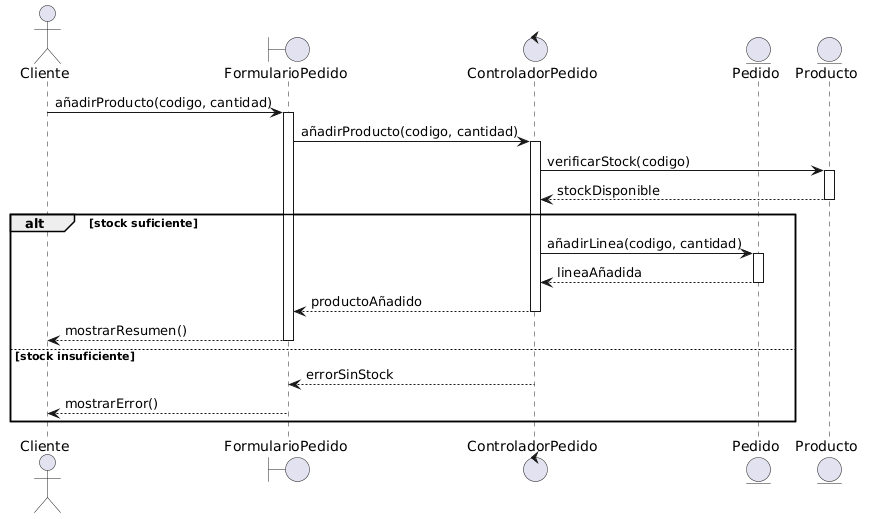

In [12]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor "Cliente" as Cl
boundary "FormularioPedido" as FP
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod

Cl -> FP: añadirProducto(codigo, cantidad)
activate FP
FP -> CP: añadirProducto(codigo, cantidad)
activate CP
CP -> Prod: verificarStock(codigo)
activate Prod
Prod --> CP: stockDisponible
deactivate Prod
alt stock suficiente
  CP -> Ped: añadirLinea(codigo, cantidad)
  activate Ped
  Ped --> CP: lineaAñadida
  deactivate Ped
  CP --> FP: productoAñadido
  deactivate CP
  FP --> Cl: mostrarResumen()
  deactivate FP
else stock insuficiente
  CP --> FP: errorSinStock
  deactivate CP
  FP --> Cl: mostrarError()
  deactivate FP
end
@enduml'''

render_plantuml(plantuml_code)


Analicemos la coherencia:

- Todos los participantes (`FormularioPedido`, `ControladorPedido`, `Pedido`, `Producto`) existen en el diagrama de clases con sus respectivos estereotipos.
- Cada mensaje se corresponde con un método declarado en la clase receptora: `añadirProducto()` en `FormularioPedido` y `ControladorPedido`, `verificarStock()` en `Producto`, `añadirLinea()` en `Pedido`.
- No aparece ningún "Sistema". La interacción se distribuye entre objetos con responsabilidades acotadas.
- El fragmento combinado `alt` modela la condición de stock, que es un flujo alternativo documentado en la especificación textual.

Este diagrama le dice al desarrollador, sin ambigüedad: "Cuando el cliente añada un producto, el formulario llamará al controlador; el controlador verificará el stock preguntándole al producto; si hay stock, añadirá una línea al pedido y retornará confirmación; si no, retornará un error al formulario". Y todo ello con objetos que ya existen en el modelo de clases, con métodos que ya están definidos.

## 3.6. Errores comunes y cómo evitarlos

A lo largo de mi carrera, estos son los fallos más recurrentes que he observado al derivar objetos para los diagramas de secuencia:

- **El "Sistema" camuflado**: a veces no se escribe "Sistema", pero se crea un participante llamado `GestorPedidos` que absorbe toda la lógica del caso de uso, sin descomponer en frontera, control y entidades. La solución es aplicar los estereotipos UML y preguntarse: "¿este objeto gestiona la interfaz con el actor, coordina la lógica de negocio o almacena datos?". Si hace las tres cosas, está mal diseñado.
- **Objetos que no están en el diagrama de clases**: si surge la necesidad de un nuevo objeto, se añade primero al modelo estructural. No se modela en el vacío.
- **Mensajes que no son métodos**: escribir `CP -> Ped: guardarEnBaseDeDatos()` cuando en la clase `Pedido` no existe ese método, sino quizás un `persistir()` delegado en un repositorio. O bien el método debe añadirse al modelo de clases, o bien el mensaje debe reflejar la operación correcta.
- **Inconsistencia en los estereotipos**: declarar un participante como `entity` en el diagrama de secuencia cuando en el de clases es `<<control>>`. La incoherencia confunde al equipo.
- **Multiplicidad de instancias ignorada**: si en el diagrama de clases un `Pedido` se compone de muchas `LineaPedido`, en el diagrama de secuencia puede ser necesario mostrar la iteración sobre esa colección (con un fragmento `loop`), en lugar de tratar `LineaPedido` como un único participante.

## 3.7. Conclusión del tema: la disciplina como ventaja competitiva

Puede parecer que estas reglas son rígidas, incluso burocráticas. Pero les aseguro que la disciplina de derivación estricta es una de las prácticas que más valor aporta a un equipo de desarrollo. Cuando todos los diagramas de secuencia se construyen con objetos que proceden del diagrama de clases, y todos los mensajes reflejan métodos reales, se produce un efecto virtuoso:

- El diagrama de clases se convierte en el diccionario central del proyecto, y todo el mundo lo consulta.
- Los diagramas de secuencia son guías de implementación directamente ejecutables.
- La revisión de pares es más rápida porque las inconsistencias saltan a la vista.
- La incorporación de nuevos miembros al equipo es más suave, porque la documentación es coherente y predecible.

En el próximo tema, daremos el paso complementario: así como los objetos derivan del modelo de clases, el comportamiento —los mensajes y su orden— deriva directamente de los casos de uso. Veremos cómo cada paso de la especificación textual se transforma en una secuencia de mensajes, y cómo los fragmentos combinados capturan las bifurcaciones y bucles que el analista funcional documentó. Con eso, cerraremos el círculo virtuoso entre requisitos, estructura y comportamiento.

# 4. Derivación del comportamiento desde los casos de uso

Hemos establecido que los objetos que pueblan nuestros diagramas de secuencia deben provenir del modelo de clases. Ahora abordamos la segunda gran derivación: el comportamiento mismo, es decir, la secuencia de mensajes que esos objetos intercambian. Este comportamiento no se inventa; se extrae meticulosamente de las especificaciones textuales de los casos de uso. Cada paso del flujo, cada condición, cada iteración y cada excepción deben tener un reflejo directo en el diagrama de secuencia. De este modo, el diagrama se convierte en la materialización dinámica de la narrativa funcional, y cualquier desarrollador o tester puede trazar un hilo directo desde la necesidad del actor hasta la última línea de código.

## 4.1. Un diagrama de secuencia, un escenario

Los casos de uso rara vez son lineales. Un caso de uso como "Realizar Pedido" contiene un flujo básico (el *happy path*), varios flujos alternativos (pago con PayPal en lugar de tarjeta, envío a sucursal) y múltiples flujos de excepción (producto sin stock, pago rechazado, error en el servicio de correo). Intentar embutir toda esa complejidad en un único diagrama de secuencia conduciría a un gráfico ilegible, plagado de fragmentos anidados y rutas imposibles de seguir.

La práctica correcta, y que he impuesto en todos mis proyectos, es asignar **un diagrama de secuencia por cada escenario relevante**. Normalmente, esto implica al menos:

- Un diagrama para el **flujo básico** completo.
- Un diagrama para cada **flujo alternativo** que tenga suficiente entidad como para merecer su propio modelado.
- Diagramas para los **flujos de excepción** más críticos o con lógica de manejo no trivial.

Esta familia de diagramas mantiene la claridad individual y, en conjunto, cubre la totalidad del caso de uso. PlantUML nos permite mantener todos estos diagramas en archivos separados, pero vinculados mediante la inclusión de un archivo común de declaración de participantes (`!include`), garantizando que los objetos sean los mismos en todos los escenarios.

## 4.2. Los mensajes como traducción de los pasos del flujo

La especificación textual de un caso de uso está redactada como una secuencia numerada de acciones que el actor y el sistema realizan. Nuestro trabajo como diseñadores es tomar cada uno de esos pasos y transformarlo en uno o varios mensajes entre los objetos participantes. No hay una correspondencia uno a uno exacta: un paso del flujo puede descomponerse en varios mensajes, o varios pasos pueden unificarse en un solo mensaje si la granularidad lo aconseja. Lo importante es que el comportamiento total del diagrama de secuencia sea **fiel** a lo que la especificación expresa.

El método que sigo es el siguiente:

1. **Leer el paso del caso de uso** y preguntarme: ¿qué objeto es el responsable de iniciar esta acción? Normalmente, si el paso dice "El Cliente hace X", el encargado de arrancar será un objeto de frontera (un formulario, una pantalla, una API). Si el paso dice "El Sistema hace Y", el encargado será un objeto de control o una entidad.
2. **Determinar el objeto receptor**: ¿quién puede ejecutar esa acción? Aquí aplico el principio de experto en información: el método debe residir en la clase que posee los datos necesarios. Por ejemplo, verificar el stock de un producto debe preguntársele al propio `Producto`, no al `Pedido`.
3. **Expresar la acción como un mensaje** con un nombre que coincida (o sugiera) el método correspondiente en el diagrama de clases.
4. **Evaluar si la acción requiere una secuencia de mensajes adicionales** (por ejemplo, antes de añadir un producto al pedido, el controlador debe verificar el stock y, si es suficiente, delegar en el `Pedido`).
5. **Identificar condiciones, bucles o paralelismo** en el flujo y traducirlos a fragmentos combinados (`alt`, `loop`, `par`, `opt`).

Veamos este proceso en acción con un ejemplo concreto.

## 4.3. Ejemplo guiado: el flujo básico de "Realizar Pedido"

Recordemos el flujo básico que hemos manejado en bloques anteriores (simplificado para centrar la atención en los pasos clave):

1. El Cliente solicita iniciar un nuevo pedido.
2. El Sistema muestra el catálogo de productos.
3. El Cliente selecciona productos y cantidades.
4. El Sistema agrega los productos al carrito y muestra un resumen.
5. El Cliente confirma el pedido.
6. El Sistema solicita la dirección de envío.
7. El Cliente ingresa la dirección.
8. El Sistema calcula el costo total y muestra el resumen final.
9. El Cliente autoriza el pago.
10. El Sistema procesa el pago, actualiza el inventario y envía confirmación.

Vamos a construir el diagrama de secuencia para este flujo básico, paso a paso, usando exclusivamente objetos de nuestro modelo de clases: `FormularioPedido` (boundary), `Catalogo` (boundary), `ControladorPedido` (control), `Pedido` (entity), `Producto` (entity), `ServicioPago` (servicio externo) y `ServicioCorreo` (servicio externo). El actor es `Cliente`.

**Paso 1** (El Cliente solicita iniciar un nuevo pedido): el actor envía un mensaje `iniciarPedido()` al `FormularioPedido`. Este, a su vez, delega en el `ControladorPedido` para que cree el pedido en el sistema. El controlador puede crear la instancia de `Pedido` con un mensaje `crear()`.


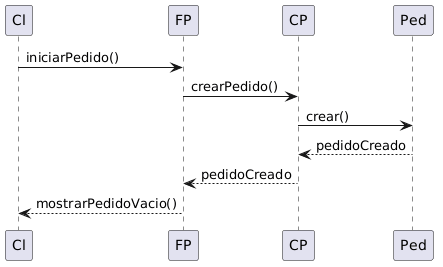

In [13]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cl -> FP: iniciarPedido()
FP -> CP: crearPedido()
CP -> Ped: crear()
Ped --> CP: pedidoCreado
CP --> FP: pedidoCreado
FP --> Cl: mostrarPedidoVacio()
@enduml'''

render_plantuml(plantuml_code)


**Paso 2** (mostrar catálogo): el formulario o el actor consultan el catálogo. Aquí podemos modelar que el `Cliente` solicita ver el catálogo al `Catalogo`, que a su vez consulta los `Producto`s disponibles.


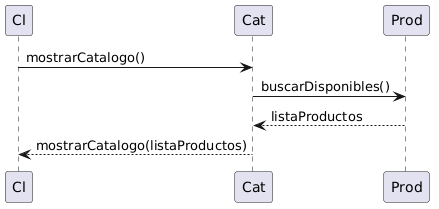

In [14]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cl -> Cat: mostrarCatalogo()
Cat -> Prod: buscarDisponibles()
Prod --> Cat: listaProductos
Cat --> Cl: mostrarCatalogo(listaProductos)
@enduml'''

render_plantuml(plantuml_code)


**Paso 3 y 4** (seleccionar productos y agregar al carrito/pedido): el cliente va añadiendo productos uno a uno. Para cada adición, se sigue el patrón que ya conocemos: el formulario llama al controlador; el controlador verifica stock en `Producto`; si hay stock, añade una línea al `Pedido`. Aquí aparece un fragmento `loop` para reflejar que el cliente puede añadir varios productos, y un fragmento `opt` o `alt` para la condición de stock. Sin embargo, el flujo básico asume que todos los productos tienen stock, por lo que en el diagrama del flujo básico podemos omitir la condición de error (o incluirla de forma simplificada). En rigor, el flujo básico es el camino sin errores, así que modelaremos solo el camino exitoso, pero dejaremos una nota de que las excepciones se tratan en otro diagrama.

Para cada producto:


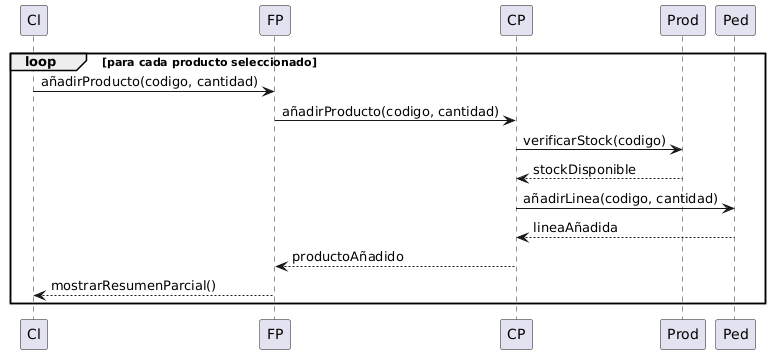

In [15]:
# Diagrama PlantUML
plantuml_code = '''@startuml
loop para cada producto seleccionado
  Cl -> FP: añadirProducto(codigo, cantidad)
  FP -> CP: añadirProducto(codigo, cantidad)
  CP -> Prod: verificarStock(codigo)
  Prod --> CP: stockDisponible
  CP -> Ped: añadirLinea(codigo, cantidad)
  Ped --> CP: lineaAñadida
  CP --> FP: productoAñadido
  FP --> Cl: mostrarResumenParcial()
end
@enduml'''

render_plantuml(plantuml_code)


**Paso 5** (confirmar pedido): el cliente confirma a través del formulario. El controlador puede validar que el pedido no esté vacío y cambiar el estado del pedido.


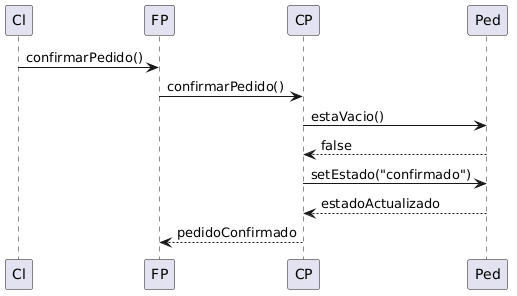

In [16]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cl -> FP: confirmarPedido()
FP -> CP: confirmarPedido()
CP -> Ped: estaVacio()
Ped --> CP: false
CP -> Ped: setEstado("confirmado")
Ped --> CP: estadoActualizado
CP --> FP: pedidoConfirmado
@enduml'''

render_plantuml(plantuml_code)


**Paso 6 y 7** (solicitar y proporcionar dirección de envío): el sistema solicita la dirección; el cliente ingresa la dirección. El formulario la pasa al controlador, que se la asigna al pedido.


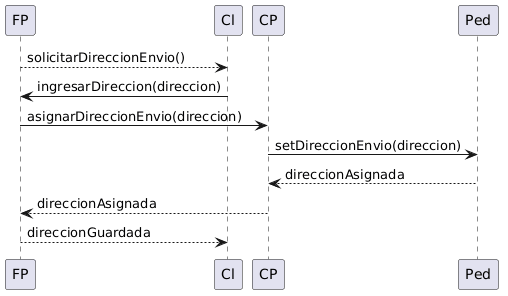

In [17]:
# Diagrama PlantUML
plantuml_code = '''@startuml
FP --> Cl: solicitarDireccionEnvio()
Cl -> FP: ingresarDireccion(direccion)
FP -> CP: asignarDireccionEnvio(direccion)
CP -> Ped: setDireccionEnvio(direccion)
Ped --> CP: direccionAsignada
CP --> FP: direccionAsignada
FP --> Cl: direccionGuardada
@enduml'''

render_plantuml(plantuml_code)


**Paso 8** (calcular costo total y mostrar resumen final): el controlador solicita al `Pedido` que calcule su total, y luego lo retorna al formulario para mostrarlo.


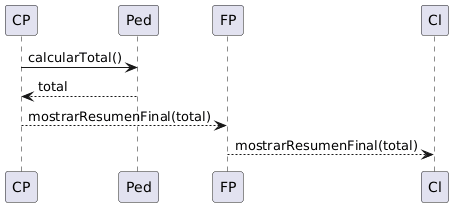

In [18]:
# Diagrama PlantUML
plantuml_code = '''@startuml
CP -> Ped: calcularTotal()
Ped --> CP: total
CP --> FP: mostrarResumenFinal(total)
FP --> Cl: mostrarResumenFinal(total)
@enduml'''

render_plantuml(plantuml_code)


**Paso 9 y 10** (autorizar pago y procesarlo): el cliente autoriza el pago. El formulario invoca al controlador, que a su vez se comunica con el `ServicioPago` externo. Si el pago es exitoso, el controlador actualiza el estado del pedido, decrementa el stock de los productos (posiblemente con un bucle sobre las líneas de pedido) y envía la confirmación mediante `ServicioCorreo`. Todo esto en el flujo básico, asumiendo éxito. Las excepciones las modelaremos aparte.


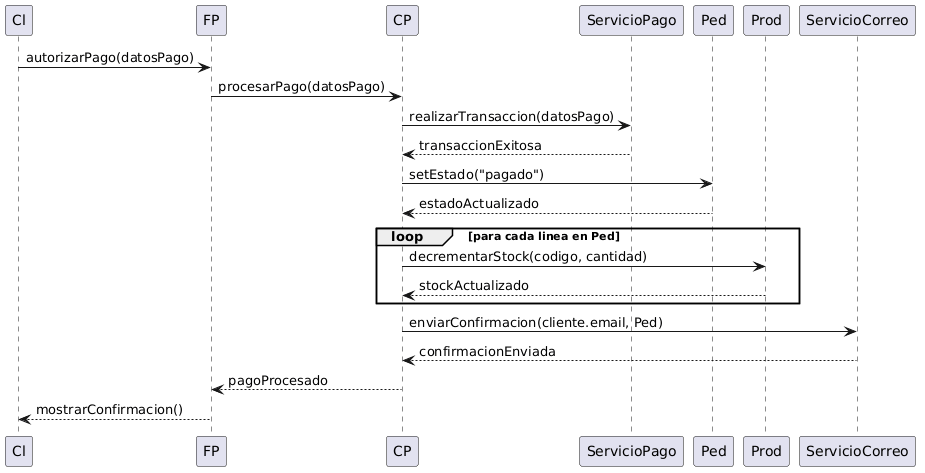

In [19]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cl -> FP: autorizarPago(datosPago)
FP -> CP: procesarPago(datosPago)
CP -> ServicioPago: realizarTransaccion(datosPago)
ServicioPago --> CP: transaccionExitosa
CP -> Ped: setEstado("pagado")
Ped --> CP: estadoActualizado
loop para cada linea en Ped
  CP -> Prod: decrementarStock(codigo, cantidad)
  Prod --> CP: stockActualizado
end
CP -> ServicioCorreo: enviarConfirmacion(cliente.email, Ped)
ServicioCorreo --> CP: confirmacionEnviada
CP --> FP: pagoProcesado
FP --> Cl: mostrarConfirmacion()
@enduml'''

render_plantuml(plantuml_code)


Hemos traducido cada paso del flujo básico a mensajes concretos, empleando los objetos del modelo de clases. El resultado es un diagrama de secuencia que narra visualmente la historia completa del caso de uso, sin ambigüedades.

## 4.4. Extensión a flujos alternativos y de excepción

El flujo básico es solo una parte de la historia. Un caso de uso robusto debe contemplar qué sucede cuando las cosas no salen como se espera. La especificación textual documenta esos caminos en secciones separadas: flujos alternativos (variantes que también terminan con éxito) y flujos de excepción (situaciones de error).

Para cada uno de estos flujos, podemos elaborar un diagrama de secuencia independiente. La ventaja de hacerlo así es que cada diagrama se mantiene simple y centrado en su propio escenario. Por ejemplo, el flujo alternativo "Pago con PayPal" reutilizaría los mismos objetos hasta el paso 8, pero a partir del paso 9, en lugar de comunicarse con `ServicioPago` genérico, lo haría con un `ServicioPayPal` específico (que debería estar en el diagrama de clases). El diagrama de este flujo alternativo sería muy similar al del flujo básico, pero con la variante en el método de pago.

Los flujos de excepción, como "Producto sin stock" o "Pago rechazado", se pueden modelar con diagramas de secuencia que parten del punto de fallo y muestran cómo el sistema maneja el error y comunica al actor. Alternativamente, si el flujo de excepción es breve, puede integrarse en el diagrama del flujo básico mediante fragmentos `alt` o `break`, aunque esto tiende a sobrecargar el diagrama. Yo recomiendo mantener los flujos de excepción en diagramas separados, sobre todo cuando implican lógica de compensación (rollback, notificaciones de error, etc.). La especificación textual debe ser la guía: si el flujo de excepción tiene su propia secuencia de pasos documentada, merece su propio diagrama.

## 4.5. Uso de fragmentos combinados para reflejar la lógica del caso de uso

Incluso dentro de un único escenario, la especificación textual puede contener estructuras de control. Ya hemos visto el uso de `loop` para iterar sobre una colección de productos. Los fragmentos combinados son la herramienta UML para trasladar esas estructuras al diagrama de secuencia de forma estandarizada. Los más relevantes son:

- **`alt`**: modela una decisión condicional con múltiples ramas. Se emplea cuando el caso de uso dice "si se cumple A, entonces... si no, entonces...". En el flujo básico no debería aparecer (porque el flujo básico es el camino sin desvíos), pero en diagramas combinados o de excepción puede que sí.
- **`opt`**: modela un paso opcional que solo se ejecuta si se cumple una condición. Por ejemplo, "si el cliente tiene un cupón, aplicar descuento".
- **`loop`**: modela una repetición. Imprescindible para "por cada producto seleccionado" o "mientras haya elementos en el carrito".
- **`break`**: modela una interrupción del flujo principal. Por ejemplo, si en mitad del proceso el cliente cierra la sesión, el flujo se interrumpe y se ejecuta una secuencia de limpieza.

Cada fragmento debe etiquetarse con una condición de guarda que parafrasee la especificación textual. Esto mantiene la trazabilidad. Por ejemplo: `loop para cada producto seleccionado` o `opt cliente tiene cupón`. La guía de PlantUML (páginas 10-12) muestra la sintaxis exacta para estos fragmentos, que ya hemos empleado en los ejemplos anteriores.

## 4.6. Validación del diagrama contra el caso de uso

Una vez construido el diagrama de secuencia para un escenario, debe ser validado contra la especificación textual. Yo suelo hacer una revisión paso a paso con el analista funcional o con el tester:

- ¿Cada paso del flujo está representado por uno o más mensajes?
- ¿Las condiciones y bucles aparecen como fragmentos combinados con sus guardas correctas?
- ¿Los mensajes de retorno llevan los datos adecuados?
- ¿Se manejan todos los caminos alternativos documentados (aunque sea en diagramas separados)?

Esta validación cierra el círculo de trazabilidad: actor -> caso de uso -> diagrama de secuencia -> diagrama de clases. Cualquier inconsistencia detectada aquí es una oportunidad de mejorar el modelo antes de escribir una sola línea de código.

## 4.7. Conclusión: la coreografía sincronizada con el guion

Derivar el comportamiento desde los casos de uso no es un ejercicio mecánico, pero sí sistemático. Requiere leer con atención la especificación, visualizar la colaboración entre los objetos de nuestro modelo de clases y expresar esa colaboración con mensajes y fragmentos combinados. El resultado es un diagrama de secuencia que no solo es técnicamente correcto, sino que cuenta la misma historia que el analista funcional escribió. Esa coherencia entre el *qué* y el *cómo* es la que convierte la documentación del proyecto en un activo fiable, y a los ingenieros de software en los verdaderos dueños del diseño.

# 5. Notación PlantUML para diagramas de secuencia

Hemos dedicado los temas anteriores a establecer los principios conceptuales y las reglas de derivación que gobiernan los diagramas de secuencia. Ahora es el momento de bajar a la trinchera de la sintaxis: cómo se escribe, en el lenguaje de PlantUML, cada uno de los elementos que hemos discutido. Porque una cosa es saber que necesitamos un objeto de control y otra muy distinta es declararlo correctamente para que el diagrama generado sea claro, profesional y mantenible.

La guía de referencia de PlantUML que venimos utilizando dedica sus primeras cuarenta y cuatro páginas a los diagramas de secuencia, y lo hace con una exhaustividad que puede resultar abrumadora si no se aborda de manera estructurada. Mi objetivo en este tema es destilar esa información en una guía práctica, organizada por los elementos que realmente utilizarán en su día a día como diseñadores: declaración de participantes, mensajes, activaciones, fragmentos combinados, numeración y notas. En cada sección, mostraré la sintaxis canónica, variantes útiles y, sobre todo, cómo cada elección sintáctica debe estar al servicio de la coherencia con el modelo de clases y los casos de uso.

## 5.1. Declaración de participantes: dando nombre a las líneas de vida

Todo diagrama de secuencia comienza declarando quiénes van a intervenir. En PlantUML, esto se hace con una serie de palabras clave que no solo crean la línea de vida, sino que además le asignan un rol visual que refuerza su significado en la arquitectura. Las palabras clave principales (páginas 2-4 de la guía) son `actor`, `boundary`, `control`, `entity`, `database`, `collections` y `participant`. Cada una dibuja un icono o una forma ligeramente distinta en la cabecera de la línea de vida.

La correspondencia con los estereotipos del diagrama de clases debe ser directa. Si en el modelo estructural tenemos una clase `FormularioPedido` con estereotipo `<<boundary>>`, en el diagrama de secuencia la declararemos como `boundary "FormularioPedido" as FP`. Si tenemos `ControladorPedido` como `<<control>>`, la declararemos como `control "ControladorPedido" as CP`. Para las entidades, usaremos `entity "Pedido" as Ped`. Para servicios externos que no son entidades, podemos usar `participant` o, si son bases de datos, `database`. La palabra `actor` queda reservada para los actores del caso de uso.

PlantUML permite abreviar la declaración usando directamente el tipo seguido del nombre. También podemos asignar un alias con `as` para simplificar los mensajes posteriores. Los nombres que contengan espacios o caracteres especiales deben ir entre comillas. Además, podemos añadir un color de fondo con `#color` después del nombre, y estereotipos adicionales con `<< >>`.

Un ejemplo de declaración para nuestro caso de uso "Realizar Pedido":


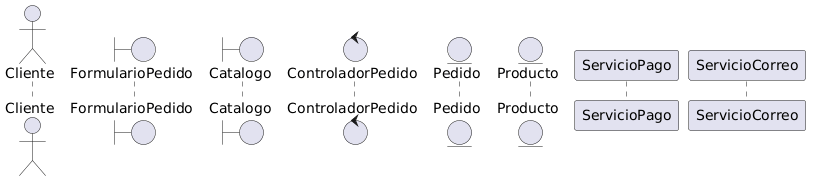

In [20]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor "Cliente" as Cl
boundary "FormularioPedido" as FP
boundary "Catalogo" as Cat
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod
participant "ServicioPago" as SP
participant "ServicioCorreo" as SC
@enduml'''

render_plantuml(plantuml_code)


Observen la coherencia: `FormularioPedido` y `Catalogo` son `boundary` porque gestionan la interacción con el actor. `ControladorPedido` es `control` porque orquesta la lógica. `Pedido` y `Producto` son `entity` porque almacenan datos persistentes. `ServicioPago` y `ServicioCorreo` se declaran como `participant` genéricos, ya que representan servicios externos. Todos ellos existen en nuestro diagrama de clases.

La guía también contempla la posibilidad de declarar participantes en varias líneas, usando `participant MultiLine`, y de cambiar el orden de impresión con la palabra clave `order` (páginas 3-4). Aunque son características menos usadas, pueden ser útiles en diagramas con muchos participantes.

## 5.2. Mensajes: el vocabulario del diálogo entre objetos

Una vez declarados los participantes, el cuerpo del diagrama se compone de mensajes. Un mensaje en PlantUML se escribe como `Emisor -> Receptor: texto`, donde `Emisor` y `Receptor` son los alias o nombres de los participantes, y `texto` es la etiqueta que aparecerá sobre la flecha. Esa etiqueta debería corresponder al nombre del método que se invoca, incluyendo parámetros si se desea un nivel de detalle más fino.

La flecha determina el tipo de mensaje (páginas 5-7):

- `->` : mensaje síncrono (línea continua, punta rellena). El emisor espera respuesta.
- `-->` : mensaje de retorno o mensaje asíncrono con línea discontinua.
- `->>` : mensaje asíncrono (punta de flecha abierta). El emisor no espera.
- `-->` : también puede usarse para retorno, a menudo con línea discontinua.
- Flechas con `\` o `/` para indicar solo la mitad inferior o superior de la punta (menos frecuentes).
- `->o` : flecha con un círculo en la punta.
- `<->` : flecha bidireccional.

La práctica más común en diagramas de diseño detallado es usar `->` para llamadas síncronas y `-->` para los retornos. Si modelamos sistemas con eventos asíncronos, emplearemos `->>`.

La etiqueta del mensaje puede contener saltos de línea con `\n` y texto multiformato usando sintaxis Creole (negritas, cursivas, etc.), como documenta la guía en la página 15 y siguientes. Esto permite que los mensajes complejos se lean con claridad.

Un aspecto fundamental es la **creación y destrucción** de objetos. PlantUML permite usar `create` antes del mensaje que crea un objeto, y `destroy` para marcar el final de su línea de vida. La sintaxis abreviada es aún más compacta: `++` activa (y crea si es necesario), `--` desactiva, `**` crea una instancia y `!!` la destruye (páginas 21-23). Esta notación es la que recomiendo para mantener la concisión.

Un ejemplo con mensajes y la notación abreviada:


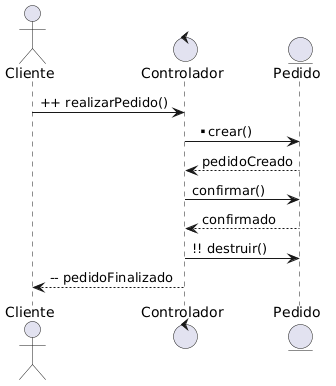

In [21]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor Cliente
control Controlador
entity Pedido

Cliente -> Controlador: ++ realizarPedido()
Controlador -> Pedido: ** crear()
Pedido --> Controlador: pedidoCreado
Controlador -> Pedido: confirmar()
Pedido --> Controlador: confirmado
Controlador -> Pedido: !! destruir()
Controlador --> Cliente: -- pedidoFinalizado
@enduml'''

render_plantuml(plantuml_code)


En este fragmento, `++` activa `Controlador`, `**` crea `Pedido`, y `!!` lo destruye. Los retornos devuelven el control.

## 5.3. Activaciones: mostrando el foco de control

Las activaciones (barras de ejecución) son los rectángulos estrechos que aparecen sobre las líneas de vida mientras un objeto ejecuta un método. En PlantUML, las activaciones pueden gestionarse automáticamente o de forma explícita.

- **Automática**: cuando usamos las flechas `->` y `-->`, PlantUML suele añadir activaciones por defecto, aunque el comportamiento exacto depende de la versión y del contexto. No siempre es fiable.
- **Explícita**: con los comandos `activate` y `deactivate` aplicados a un participante. Por ejemplo: `activate Controlador` y luego `deactivate Controlador`. Esto da un control total sobre cuándo comienza y termina cada barra.
- **Abreviada**: los ya mencionados `++` y `--` al final de un mensaje activan o desactivan al receptor, y también desactivan al emisor si se usan en el retorno. Esta es la notación que yo prefiero, porque ahorra líneas y mantiene el foco en el flujo principal.

La guía (página 19-21) muestra ejemplos detallados de cómo las activaciones anidadas reflejan la pila de llamadas. Un objeto puede estar activo, recibir un mensaje, activar a su vez a otro, y así sucesivamente. Cuando el objeto más interno termina su trabajo, se desactiva y devuelve el control al objeto que lo llamó. Las activaciones dibujan este proceso con una claridad insuperable.

Es importante no abusar de las activaciones. En diagramas muy simples, pueden omitirse sin pérdida de información. En diagramas con varias llamadas anidadas, son casi imprescindibles para entender quién está esperando a quién.

## 5.4. Fragmentos combinados: tejiendo la lógica de control

Los fragmentos combinados son la herramienta de PlantUML para expresar condiciones, bucles, paralelismo y otras estructuras de control dentro del diagrama de secuencia. Se delimitan con palabras clave que se abren y se cierran con `end`, y pueden anidarse. La guía (páginas 10-12) detalla los siguientes:

- `alt` / `else` : condición múltiple. Cada región tiene una guarda (opcional) entre paréntesis.
- `opt` : condición opcional, similar a un `if` sin `else`.
- `loop` : repetición. Puede llevar una condición (`loop while`) o un número de iteraciones (`loop 1000 times`).
- `par` : ejecución en paralelo. Las regiones internas se ejecutan concurrentemente.
- `break` : interrupción de la secuencia principal si se cumple la guarda.
- `critical` : región que no puede ser interrumpida.
- `group` : agrupación genérica con una etiqueta textual.

La sintaxis de todos sigue el patrón:


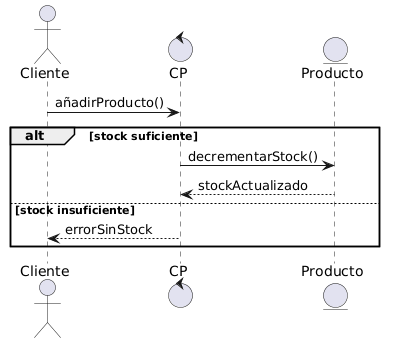

In [22]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor Cliente
control CP
entity Producto

Cliente -> CP: añadirProducto()
alt stock suficiente
  CP -> Producto: decrementarStock()
  Producto --> CP: stockActualizado
else stock insuficiente
  CP --> Cliente: errorSinStock
end
@enduml'''

render_plantuml(plantuml_code)


Los fragmentos deben incluir guardas que parafraseen la especificación textual del caso de uso. Así se mantiene la trazabilidad y se facilita la validación. En el ejemplo, "stock suficiente" y "stock insuficiente" son condiciones que aparecen en el flujo alternativo de "Realizar Pedido".

Para bucles:


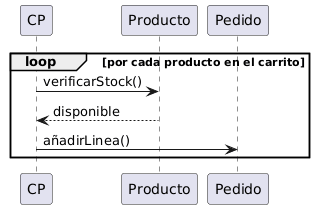

In [23]:
# Diagrama PlantUML
plantuml_code = '''@startuml
loop por cada producto en el carrito
  CP -> Producto: verificarStock()
  Producto --> CP: disponible
  CP -> Pedido: añadirLinea()
end
@enduml'''

render_plantuml(plantuml_code)


Y para operaciones opcionales:


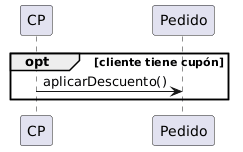

In [24]:
# Diagrama PlantUML
plantuml_code = '''@startuml
opt cliente tiene cupón
  CP -> Pedido: aplicarDescuento()
end
@enduml'''

render_plantuml(plantuml_code)


Los fragmentos anidados deben usarse con moderación. Si la lógica se vuelve muy compleja, es mejor extraer subescenarios a diagramas de secuencia separados y referenciarlos mediante `ref` (página 16). La regla general es que un diagrama de secuencia no debería tener más de dos o tres niveles de anidamiento.

## 5.5. Numeración de mensajes

PlantUML proporciona la palabra clave `autonumber` para añadir automáticamente números a los mensajes, lo cual es extremadamente útil para referenciarlos en la documentación, en revisiones o en las pruebas. La numeración puede configurarse en formato, inicio e incremento (páginas 7-9).

- `autonumber` : inicia la numeración en 1 con formato por defecto.
- `autonumber 10` : inicia en 10.
- `autonumber 15 2` : inicia en 15 e incrementa de 2 en 2.
- `autonumber "<b>[00]"` : formato con HTML (negrita, corchetes, etc.).
- `autonumber stop` y `autonumber resume` para pausar y reanudar la numeración.

Un ejemplo:


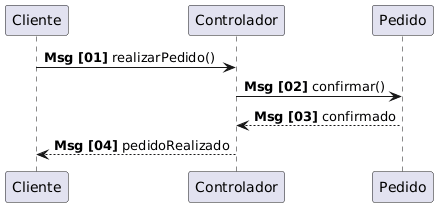

In [25]:
# Diagrama PlantUML
plantuml_code = '''@startuml
autonumber "<b>Msg [00]</b>"
Cliente -> Controlador: realizarPedido()
Controlador -> Pedido: confirmar()
Pedido --> Controlador: confirmado
Controlador --> Cliente: pedidoRealizado
@enduml'''

render_plantuml(plantuml_code)


Esto numerará los mensajes como "Msg 01", "Msg 02", etc., en negrita. La numeración no afecta la semántica del diagrama, pero simplifica enormemente la comunicación: "Revisemos el mensaje 03 del diagrama de secuencia del flujo básico".

## 5.6. Notas y comentarios

Las notas son fragmentos de texto que se adhieren al diagrama para aclarar condiciones, explicar decisiones de diseño o enlazar con otros artefactos. PlantUML ofrece varias posiciones para las notas:

- `note left of` / `note right of` / `note top of` / `note bottom of` aplicadas a un participante concreto.
- `note left` / `note right` sobre un mensaje (colocándola inmediatamente después de la definición del mensaje).
- `note over` para cubrir uno o varios participantes (por ejemplo, `note over Alice, Bob`).
- `note across` para una nota que abarque todas las líneas de vida (páginas 13-14).

Las notas pueden ser multilínea usando `end note`. También aceptan formato Creole y HTML (negritas, cursivas, colores, etc., página 15). Incluso pueden cambiarse de forma con `hnote` y `rnote` (hexagonal y rectangular respectivamente, página 13).

Un ejemplo con notas:


In [ ]:
# Diagrama PlantUML
plantuml_code = '''@startuml
Cliente -> Servidor: solicitarDatos()
note right of Servidor: Este método puede lanzar\nuna excepción si el timeout se agota.
Servidor --> Cliente: datos
note left of Cliente: La respuesta debe mostrarse\nen menos de 2 segundos.
@enduml'''

render_plantuml(plantuml_code)
#Si lo copian y pegan en la pagina de plantUML funciona acá no he encontrado qué falla

[WARN] No se pudo renderizar el diagrama (sin conexion al servidor PlantUML).
Codigo fuente:
```plantuml
@startuml
Cliente -> Servidor: solicitarDatos()
note right of Servidor: Este método puede lanzar
una excepción si el timeout se agota.
Servidor --> Cliente: datos
note left of Cliente: La respuesta debe mostrarse
en menos de 2 segundos.
@enduml
```


Las notas son el lugar ideal para registrar aclaraciones que no forman parte del flujo narrativo pero que son valiosas para el desarrollador o el tester. En mis diagramas, suelo incluir una nota que enlace al código del caso de uso (`[[CU-01]]`) o al diagrama de clases de referencia.

## 5.7. Personalización visual para una comunicación efectiva

Aunque la notación por defecto de PlantUML es clara y profesional, hay situaciones en las que necesitamos personalizar la apariencia para adaptarla a la audiencia o para resaltar ciertos aspectos del diseño. La guía (páginas 28-32) dedica una sección extensa a `skinparam` y a las opciones de estilo. Algunos parámetros relevantes son:

- `skinparam sequenceArrowThickness` : grosor de las flechas.
- `skinparam sequenceMessageAlign` : alineación del texto de los mensajes (`left`, `right`, `center`, `direction`).
- `skinparam responseMessageBelowArrow true` : coloca el texto del mensaje de respuesta debajo de la flecha.
- `skinparam maxMessageSize` : ajusta la longitud máxima de los mensajes antes de que PlantUML los parta automáticamente.
- `skinparam participant` y `skinparam actor` : colores, fuentes y bordes de los participantes.
- `skinparam lifelineStrategy solid` : para líneas de vida sólidas en lugar de discontinuas.

También podemos aplicar estilos globales con la etiqueta `<style>` y selectores CSS-like, como se muestra en la página 143 y siguientes de la guía (aunque esa sección es más específica para otros diagramas, la sintaxis es compatible con elementos de secuencia en versiones recientes). En general, recomiendo usar `skinparam` de manera conservadora, definiendo una paleta de colores y estilos al inicio del archivo, para mantener consistencia en toda la documentación.

## 5.8. La notación al servicio del diseño: buenas prácticas de escritura

Para cerrar este tema, quiero dejar una serie de recomendaciones prácticas sobre cómo escribir los archivos `.puml` de diagramas de secuencia:

- **Encabezado con comentarios**: al inicio del archivo, incluir un comentario que indique el caso de uso y el escenario modelado. Por ejemplo: `' Diagrama de secuencia: flujo básico de Realizar Pedido (CU-01)`.
- **Declaración ordenada de participantes**: agrupar las declaraciones por tipo (actores, boundaries, controles, entidades, servicios) y en orden de aparición aproximada en el flujo. Esto facilita la lectura del código fuente.
- **Alias significativos**: usar alias cortos pero descriptivos (`FP` para `FormularioPedido`, `CP` para `ControladorPedido`). Evitar alias genéricos como `A`, `B`, `C`.
- **Mensajes que reflejen métodos**: la etiqueta del mensaje debe ser el nombre del método (o al menos una paráfrasis cercana). Si el método tiene parámetros relevantes, incluirlos entre paréntesis.
- **Fragmentos combinados con guardas explícitas**: nunca dejar una guarda vacía o ambigua. Si la especificación textual dice "si el producto está agotado", la guarda debe ser `producto agotado`.
- **Notas para aclaraciones, no para narrativa**: no usar notas para suplir la falta de mensajes. Si un paso del caso de uso no está modelado, añadir los mensajes correspondientes, no una nota que diga "aquí se haría tal cosa".
- **Mantener el diagrama actualizado**: si el caso de uso cambia, actualizar el diagrama de secuencia en el mismo commit, igual que se hace con el código.

Con esta notación en su caja de herramientas, están en condiciones de plasmar cualquier interacción por compleja que sea, siempre respetando las reglas de derivación que hemos establecido. En el próximo tema, recorreremos el proceso completo, paso a paso, para que puedan aplicar esta notación de manera sistemática en sus proyectos.

# 6. Proceso paso a paso para construir un diagrama de secuencia

Hemos desmenuzado la teoría, los elementos y las reglas de derivación. Ha llegado la hora de ensamblar todo ese conocimiento en un método reproducible. A lo largo de este tema, les guiaré por el proceso completo que yo mismo sigo cuando me siento con el equipo a transformar una especificación textual en un diagrama de secuencia. No es una receta mecánica, pero sí una secuencia lógica de decisiones que, aplicada con disciplina, garantiza que el diagrama resultante sea coherente, completo y útil.

El escenario que utilizaremos como hilo conductor será, una vez más, el flujo básico de "Realizar Pedido", nuestro caso de uso de referencia. Asumiremos que ya contamos con un diagrama de clases consolidado y con la especificación textual del caso de uso. El objetivo es construir el diagrama de secuencia que materializa ese flujo básico, respetando escrupulosamente las reglas de derivación que hemos establecido.

## 6.1. Paso 1: Seleccionar el caso de uso y el escenario

Lo primero es acotar con precisión qué vamos a modelar. No modelamos "todo el sistema", ni siquiera "todo el caso de uso". Modelamos **un escenario concreto**: el flujo básico, un flujo alternativo o un flujo de excepción. Para cada uno elaboraremos un diagrama de secuencia independiente.

En nuestro caso, el escenario elegido es el flujo básico de "Realizar Pedido", que describe el camino exitoso desde que el cliente decide iniciar un pedido hasta que recibe la confirmación de que todo ha ido bien. Es el *happy path* por excelencia, y por eso es el primer diagrama que debemos construir.

Antes de escribir una sola línea de PlantUML, conviene tener a mano la especificación textual del flujo básico, ya sea impresa o en una ventana adyacente. Ese texto será nuestra guía constante.

## 6.2. Paso 2: Identificar los objetos participantes desde el diagrama de clases y el flujo

Ahora nos preguntamos: ¿qué objetos necesitan intervenir para que este flujo se cumpla? La respuesta no la inventamos; la extraemos del diagrama de clases y de los roles que el propio flujo sugiere.

Abrimos nuestro diagrama de clases del sistema. Allí tenemos, entre otras, las siguientes clases relevantes para "Realizar Pedido":

- **Frontera**: `FormularioPedido`, `Catalogo`. Gestionan la interacción con el actor.
- **Control**: `ControladorPedido`, `Carrito`. Orquestan la lógica del caso de uso.
- **Entidad**: `Pedido`, `Producto`, `LineaPedido`, `Cliente`. Almacenan los datos del dominio.
- **Servicio**: `ServicioPago`, `ServicioCorreo`. Representan integraciones externas.

Además, el actor `Cliente` es el que inicia la interacción. Todos estos participantes tienen su correspondiente clase en el modelo estructural. Si durante el diseño del diagrama de secuencia echásemos en falta algún objeto, volveríamos al diagrama de clases para añadirlo formalmente antes de continuar.

El resultado de este paso es una lista de participantes que declararemos en el paso siguiente. No es una lista cerrada; puede refinarse, pero debe tener una correspondencia biunívoca con las clases existentes.

## 6.3. Paso 3: Dibujar las líneas de vida de todos los participantes

Con la lista de participantes sobre la mesa, abrimos un nuevo archivo `.puml` y declaramos cada línea de vida usando la palabra clave que mejor refleje su rol en la arquitectura. Yo suelo seguir este orden: actor, fronteras, controles, entidades, servicios. Es un orden lógico que facilita la lectura.

Para nuestro escenario, la declaración inicial quedaría así:


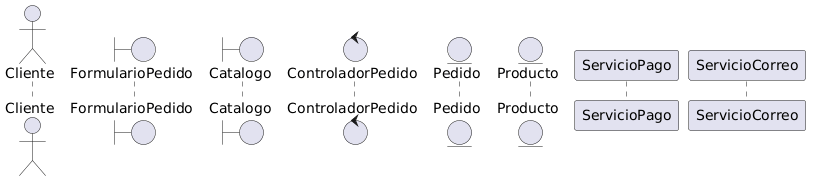

In [31]:
# Diagrama PlantUML
plantuml_code = '''@startuml
' Flujo básico de Realizar Pedido (CU-01)
actor "Cliente" as Cl
boundary "FormularioPedido" as FP
boundary "Catalogo" as Cat
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod
participant "ServicioPago" as SP
participant "ServicioCorreo" as SC
@enduml'''

render_plantuml(plantuml_code)


He incluido un comentario al inicio para identificar el escenario. Cada participante tiene un alias corto pero descriptivo. Las declaraciones son explícitas respecto al rol arquitectónico. A partir de este esqueleto, comenzaremos a tejer los mensajes.

## 6.4. Paso 4: Recorrer el flujo y decidir los mensajes entre objetos

Este es el núcleo del proceso. Tomamos la especificación textual del flujo básico y, paso a paso, la traducimos a mensajes entre los participantes que hemos declarado. La pregunta que nos hacemos para cada paso es doble: ¿qué objeto debe iniciar esta acción? ¿Qué objeto es el responsable de llevarla a cabo según sus métodos y atributos?

Recorramos el flujo básico paso a paso y anotemos los mensajes correspondientes. Lo haré de manera textual y luego lo plasmaré en el código PlantUML.

**Paso 1 del caso de uso:** "El Cliente solicita iniciar un nuevo pedido".

El actor `Cliente` interactúa con la interfaz; por tanto, envía un mensaje `iniciarPedido()` al `FormularioPedido`. El formulario, a su vez, delega en el `ControladorPedido` mediante `crearPedido()`. El controlador crea la instancia de `Pedido` con un mensaje `crear()`. Los retornos confirman la creación y el formulario muestra el pedido vacío al actor.

**Paso 2:** "El Sistema muestra el catálogo de productos".

El `Cliente` solicita el catálogo al `Catalogo`. Este consulta los productos disponibles mediante `buscarDisponibles()` a la entidad `Producto` (o a un repositorio de productos, si lo hemos modelado). El catálogo recibe la lista y la muestra al actor.

**Paso 3 y 4:** "El Cliente selecciona productos y cantidades. El Sistema los agrega al pedido y muestra un resumen".

Aquí hay una repetición implícita: el cliente puede añadir varios productos. Por tanto, necesitaremos un fragmento `loop`. Dentro del bucle, para cada producto, el `Cliente` envía `añadirProducto(codigo, cantidad)` al `FormularioPedido`. El formulario lo pasa al controlador, que verifica el stock en `Producto` (`verificarStock(codigo)`). Si hay stock, el controlador añade una línea al `Pedido` (`añadirLinea(codigo, cantidad)`) y luego devuelve la confirmación hasta el formulario, que muestra el resumen actualizado. La comprobación de stock insuficiente pertenece a un flujo de excepción, así que en el flujo básico asumiremos que siempre hay stock (o podemos incluir un fragmento `opt` con la condición, pero para mantener la pureza del *happy path*, a menudo lo omitimos y dejamos una nota). En este ejemplo, lo modelaremos con un `alt` que solo tenga la rama de éxito, con una nota que indique que la excepción se trata en otro diagrama. Aunque rigurosamente el flujo básico no debería contener condiciones, muchos diseñadores incluyen la condición de éxito explícitamente para clarificar que se asume stock suficiente. Ambas opciones son válidas, pero debemos documentar la decisión.

**Paso 5:** "El Cliente confirma el pedido".

El actor envía `confirmarPedido()` al formulario, que llama al controlador. El controlador verifica que el pedido no esté vacío (`estaVacio()`), cambia su estado a "confirmado" (`setEstado("confirmado")`) y retorna la confirmación al formulario, que se la muestra al actor.

**Paso 6 y 7:** "El Sistema solicita la dirección de envío. El Cliente ingresa la dirección".

El formulario muestra una petición de dirección. El actor introduce la dirección y la envía. El formulario la pasa al controlador (`asignarDireccionEnvio(direccion)`), que la asigna al `Pedido` (`setDireccionEnvio(direccion)`). La confirmación regresa hasta el actor.

**Paso 8:** "El Sistema calcula el costo total y muestra el resumen final".

El controlador pide al `Pedido` que calcule su total (`calcularTotal()`) y envía el resultado al formulario, que lo muestra al actor.

**Paso 9 y 10:** "El Cliente autoriza el pago. El Sistema procesa el pago, actualiza el inventario y envía confirmación".

El actor proporciona los datos de pago al formulario. El formulario invoca al controlador (`procesarPago(datosPago)`). El controlador se comunica con el `ServicioPago` externo (`realizarTransaccion(datosPago)`). Si la transacción es exitosa, el controlador actualiza el estado del pedido a "pagado", itera sobre las líneas del pedido para decrementar el stock de cada producto (`decrementarStock(codigo, cantidad)`), y finalmente solicita al `ServicioCorreo` que envíe la confirmación (`enviarConfirmacion(cliente.email, Ped)`). El controlador retorna éxito al formulario, que muestra la confirmación al actor.

Esta traducción es la esencia de la derivación. He respetado el principio de experto: `Producto` verifica y decrementa su propio stock; `Pedido` sabe calcular su total; el controlador no contiene lógica de negocio, solo orquesta. Todos los métodos mencionados deben existir en el diagrama de clases. Si alguno faltara, habría que añadirlo antes de considerar completo el diseño.

## 6.5. Paso 5: Añadir activaciones para mostrar el foco de control

Con los mensajes definidos, activamos las barras de ejecución para que el diagrama refleje la pila de llamadas. Utilizaré la notación abreviada `++` y `--` por su limpieza.

- Cuando un objeto recibe un mensaje que inicia un bloque de trabajo, añado `++` al final de la flecha de entrada.
- Cuando ese objeto retorna y cede el control, uso `--` en el mensaje de retorno.
- Si un objeto crea a otro, uso `**` en lugar de `++`.
- Si un objeto es destruido, uso `!!` o `destroy`.

En el flujo básico, `Pedido` se crea y no se destruye dentro del propio flujo; permanece vivo. `Producto` solo recibe consultas. Los servicios externos pueden o no activarse, dependiendo de si queremos mostrar su ejecución interna; en general, para servicios externos, no modelo su activación porque no controlamos su código, pero sí la del controlador que los invoca.

## 6.6. Paso 6: Incluir fragmentos combinados según la lógica del flujo

Aunque el flujo básico es lineal por definición, en la práctica aparecen estructuras de control. En nuestro caso, necesitamos:

- Un `loop` para "por cada producto seleccionado".
- Opcionalmente, un `opt` para la condición de stock suficiente en el flujo básico, o simplemente omitirlo y confiar en que el camino feliz asume éxito. Yo optaré por un `alt` con solo la rama exitosa, documentando con una nota que la rama de error se trata en otro diagrama. Esto da mayor claridad visual.
- No necesitamos otros fragmentos en el flujo básico.

La inclusión de estos fragmentos transforma el diagrama en un reflejo fiel de la narrativa funcional.

## 6.7. El diagrama completo resultante

Aplicando los pasos anteriores, el código PlantUML para el flujo básico de "Realizar Pedido" quedaría como se muestra a continuación. He incorporado todos los elementos discutidos: declaraciones de participantes, mensajes con activación abreviada, fragmentos combinados y una nota que remite a los flujos de excepción.


In [ ]:
# Diagrama PlantUML
plantuml_code = '''@startuml
' Flujo básico: Realizar Pedido (CU-01)
autonumber "<b>[00]</b>"

actor "Cliente" as Cl
boundary "FormularioPedido" as FP
boundary "Catalogo" as Cat
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod
participant "ServicioPago" as SP
participant "ServicioCorreo" as SC

' Paso 1: Iniciar pedido
Cl -> FP: iniciarPedido()
FP -> CP: ++ crearPedido()
CP -> Ped: ** crear()
Ped --> CP: pedidoCreado
CP --> FP: -- pedidoCreado
FP --> Cl: mostrarPedidoVacio()

' Paso 2: Mostrar catálogo
Cl -> Cat: mostrarCatalogo()
Cat -> Prod: buscarDisponibles()
Prod --> Cat: listaProductos
Cat --> Cl: mostrarCatalogo(listaProductos)

' Pasos 3 y 4: Añadir productos
loop para cada producto seleccionado
  Cl -> FP: añadirProducto(codigo, cantidad)
  FP -> CP: ++ añadirProducto(codigo, cantidad)
  alt stock suficiente
    CP -> Prod: verificarStock(codigo)
    Prod --> CP: stockDisponible
    CP -> Ped: añadirLinea(codigo, cantidad)
    Ped --> CP: lineaAñadida
    CP --> FP: -- productoAñadido
    FP --> Cl: mostrarResumenParcial()
  end
end
note right of CP: El caso de stock insuficiente\nse modela en el diagrama de excepción.

' Paso 5: Confirmar pedido
Cl -> FP: confirmarPedido()
FP -> CP: ++ confirmarPedido()
CP -> Ped: estaVacio()
Ped --> CP: false
CP -> Ped: setEstado("confirmado")
Ped --> CP: estadoActualizado
CP --> FP: -- pedidoConfirmado
FP --> Cl: pedidoConfirmado

' Pasos 6 y 7: Dirección de envío
FP --> Cl: solicitarDireccionEnvio()
Cl -> FP: ingresarDireccion(direccion)
FP -> CP: ++ asignarDireccionEnvio(direccion)
CP -> Ped: setDireccionEnvio(direccion)
Ped --> CP: direccionAsignada
CP --> FP: -- direccionAsignada
FP --> Cl: direccionGuardada

' Paso 8: Calcular total y mostrar resumen
CP -> Ped: calcularTotal()
Ped --> CP: total
CP --> FP: -- mostrarResumenFinal(total)
FP --> Cl: mostrarResumenFinal(total)

' Pasos 9 y 10: Pago y confirmación
Cl -> FP: autorizarPago(datosPago)
FP -> CP: ++ procesarPago(datosPago)
CP -> SP: realizarTransaccion(datosPago)
SP --> CP: transaccionExitosa
CP -> Ped: setEstado("pagado")
Ped --> CP: estadoActualizado
loop para cada linea del pedido
  CP -> Prod: decrementarStock(codigo, cantidad)
  Prod --> CP: stockActualizado
end
CP -> SC: enviarConfirmacion(cliente.email, Ped)
SC --> CP: confirmacionEnviada
CP --> FP: -- pagoProcesado
FP --> Cl: mostrarConfirmacion()

@enduml'''

render_plantuml(plantuml_code)

#Lo mismo, en la pagina corre perfectamente


[WARN] No se pudo renderizar el diagrama (sin conexion al servidor PlantUML).
Codigo fuente:
```plantuml
@startuml
' Flujo básico: Realizar Pedido (CU-01)
autonumber "<b>[00]</b>"

actor "Cliente" as Cl
boundary "FormularioPedido" as FP
boundary "Catalogo" as Cat
control "ControladorPedido" as CP
entity "Pedido" as Ped
entity "Producto" as Prod
participant "ServicioPago" as SP
participant "ServicioCorreo" as SC

' Paso 1: Iniciar pedido
Cl -> FP: iniciarPedido()
FP -> CP: ++ crearPedido()
CP -> Ped: ** crear()
Ped --> CP: pedidoCreado
CP --> FP: -- pedidoCreado
FP --> Cl: mostrarPedidoVacio()

' Paso 2: Mostrar catálogo
Cl -> Cat: mostrarCatalogo()
Cat -> Prod: buscarDisponibles()
Prod --> Cat: listaProductos
Cat --> Cl: mostrarCatalogo(listaProductos)

' Pasos 3 y 4: Añadir productos
loop para cada producto seleccionado
  Cl -> FP: añadirProducto(codigo, cantidad)
  FP -> CP: ++ añadirProducto(codigo, cantidad)
  alt stock suficiente
    CP -> Prod: verificarStock(codigo)
    Prod -->

Observen cómo el diagrama narra visualmente la historia completa. Cada paso del caso de uso tiene su reflejo en mensajes. Los objetos son exactamente los del diagrama de clases. La numeración automática permite referenciar cada mensaje sin ambigüedad. Las activaciones muestran la profundidad de las llamadas. Y la nota recuerda que el camino de error está documentado aparte.

## 6.8. Paso 7: Validar el diagrama contra el caso de uso y el modelo de clases

Nunca doy por terminado un diagrama de secuencia sin una validación explícita. Repaso mentalmente (o con el equipo) las siguientes comprobaciones:

- **Objetos válidos**: cada línea de vida que no es un actor está en el diagrama de clases. Si no es así, vuelvo al modelo estructural y lo actualizo.
- **Métodos reales**: cada mensaje enviado a un objeto corresponde a un método definido en su clase. Reviso que los nombres, parámetros y tipos de retorno sean coherentes.
- **Cobertura del flujo**: cada paso de la especificación textual está cubierto por uno o más mensajes. Si un paso queda sin representar, añado los mensajes necesarios.
- **Corrección de la lógica**: los fragmentos combinados (`loop`, `alt`, `opt`) reflejan exactamente las condiciones y repeticiones del texto. Las guardas son claras y parafrasean la especificación.
- **Claridad narrativa**: alguien que no conoce el detalle del caso de uso debería poder leer el diagrama y entender la secuencia de interacciones sin necesidad de consultar el texto. La combinación de mensajes, activaciones y fragmentos debe contar la historia por sí sola.

Esta validación es el equivalente a la revisión de código en programación. Si se hace sistemáticamente, los defectos de diseño se detectan en la fase de modelado, no durante la codificación.

## 6.9. Iteración y refinamiento

El primer diagrama rara vez es perfecto. A medida que se modelan los flujos alternativos y de excepción, pueden surgir necesidades que obliguen a retocar el flujo básico: un nuevo objeto de servicio que también debe intervenir, un método que se había omitido, una validación adicional. Esto es normal. El diagrama de secuencia no es un monumento inamovible; es un artefacto vivo que evoluciona junto con el entendimiento del sistema.

PlantUML hace que esta evolución sea indolora. Editar el archivo `.puml`, regenerar la imagen y compararla con la versión anterior es cuestión de segundos. Por eso insisto tanto en que los diagramas deben residir en el repositorio de código, bajo control de versiones.

## 6.10. Conclusión del proceso

Seguir estos siete pasos no garantiza la perfección, pero sí la coherencia. La secuencia es lógica: primero acotamos el escenario, luego identificamos los actores y objetos que intervienen, dibujamos sus líneas de vida, traducimos la narrativa a mensajes, añadimos las activaciones y la lógica de control, y finalmente validamos con los artefactos de referencia. Este método, aplicado una y otra vez, se convierte en un hábito mental que acelera el diseño y mejora su calidad.

En el próximo tema, el último de este bloque sobre diagramas de secuencia, recopilaremos las buenas prácticas y los errores más frecuentes que he observado en mi trayectoria, para que ustedes sepan no solo cómo construir estos diagramas, sino cómo hacerlo de forma profesional, mantenible y alineada con el resto de la documentación del proyecto.

# 7. Buenas prácticas y errores comunes en la construcción de diagramas de secuencia

Hemos recorrido un largo camino desde los fundamentos del diagrama de secuencia hasta un método paso a paso para construirlo. Pero la diferencia entre un diagrama “que funciona” y un diagrama que realmente aporta valor al proyecto no reside en la técnica básica, sino en la disciplina con la que se aplican ciertos principios y en la capacidad para evitar vicios que, como un mal hábito, se arraigan sutilmente en los equipos. En este tema final, quiero compartir con ustedes el destilado de muchas revisiones de diseño: las prácticas que elevan la calidad del modelado dinámico y los errores que una y otra vez he tenido que corregir para que los diagramas de secuencia fuesen herramientas de ingeniería y no meros adornos visuales.

## 7.1. No inventar objetos: el modelo de clases como fuente única de verdad

Éste es, sin duda, el principio más importante y el que con más firmeza he impuesto en todos mis proyectos: **cada línea de vida que no sea un actor debe estar respaldada por una clase en el diagrama de clases**. No hay atajos ni excepciones. Si durante la elaboración de un diagrama de secuencia surge la necesidad de un objeto que no existe en el modelo estructural, el diagrama de secuencia debe detenerse, no completarse.

¿Por qué tanta rigidez? Porque el diagrama de clases representa el contrato estructural del sistema. Si el diagrama de secuencia introduce objetos no declarados, estamos modelando un comportamiento sin base estructural, lo que equivale a diseñar los movimientos de un edificio sin haber definido sus pilares. Tarde o temprano, esa incoherencia se traduce en código inconsistente y en documentación que nadie respeta.

La práctica correcta es la siguiente: si surgen objetos adicionales durante el modelado dinámico —algo frecuente y saludable, pues el diagrama de secuencia es una excelente herramienta de validación del modelo de clases—, debemos volver al diagrama de clases, justificar la nueva clase en el contexto de los casos de uso, definir sus atributos, métodos y relaciones, y solo entonces incorporarla al diagrama de secuencia. Este flujo bidireccional entre lo estático y lo dinámico es lo que mantiene robusto el diseño.

## 7.2. No usar un "objeto Sistema": descomponer en frontera, control y entidad

El error más común que encuentro en ingenieros que se inician en UML es dibujar un único participante llamado “Sistema” que recibe todos los mensajes del actor y, como por arte de magia, resuelve el caso de uso. Este vicio puede parecer inofensivo pero es profundamente dañino.

El “Sistema” omnisciente viola el principio de responsabilidad única, oculta la complejidad real ocultando la colaboración entre objetos y, sobre todo, impide la trazabilidad con el diagrama de clases. Si todo lo hace un ente abstracto, ¿dónde quedan las clases que cuidadosamente modelamos? ¿Qué utilidad tiene un diagrama de secuencia que no muestra cómo nuestros objetos colaboran?

La alternativa es descomponer el “Sistema” empleando los estereotipos de UML que PlantUML soporta de forma nativa:

- **Objetos de frontera (`<<boundary>>`)**: encapsulan la interacción con el actor. Son las pantallas, formularios o APIs que traducen las acciones del actor en mensajes hacia el interior del sistema y viceversa.
- **Objetos de control (`<<control>>`)**: orquestan la lógica del caso de uso. No almacenan datos persistentes ni interactúan directamente con el actor, sino que coordinan a las entidades y los servicios.
- **Objetos de entidad (`<<entity>>`)**: representan los datos del dominio que persisten más allá de la ejecución del caso de uso.
- **Servicios y recursos externos**: representados como `participant` o `actor` secundario, según su naturaleza.

En PlantUML, cada uno de estos roles se declara con la palabra reservada correspondiente: `boundary`, `control`, `entity`, `participant`. El resultado no es un diagrama más complejo, sino un diagrama más informativo, que guía al desarrollador sobre la arquitectura interna esperada y refleja exactamente las clases del modelo estructural.

## 7.3. Mantener el nivel de abstracción correcto

El diagrama de secuencia no es un sustituto del código fuente; es un plano de diseño que debe mantenerse en el nivel adecuado de abstracción. Esto implica que los mensajes deben reflejar **operaciones del dominio** y no detalles de implementación.

Un mensaje como `recuperarProductoPorId(id)` puede ser aceptable si estamos modelando la interacción con un repositorio, pero `ejecutarConsultaSQL(query)` no lo es jamás en un diagrama de secuencia de diseño. De igual modo, no deberíamos incluir mensajes que reflejen mecánicas de un framework específico (`deserializarJSON`, `inyectarDependencia`), a menos que estemos modelando un diagrama de secuencia de infraestructura muy detallado.

La pregunta que formulo para mantener el nivel de abstracción es: “Si cambiáramos la tecnología subyacente, ¿este mensaje seguiría siendo válido?”. Si la respuesta es no, probablemente estamos descendiendo demasiado.

## 7.4. Cuidar la legibilidad

Un diagrama de secuencia con quince líneas de vida, cincuenta mensajes y cuatro niveles de fragmentos anidados no comunica, aturde. La legibilidad es un requisito no funcional del propio diagrama. Algunas estrategias para mantenerla:

- **Limitar el número de participantes a los estrictamente necesarios para el escenario**. Si un objeto solo aparece en dos mensajes, quizás pueda omitirse y anotar su intervención con una nota.
- **Reducir la longitud de los mensajes**. Usar alias cortos pero descriptivos. Si un método tiene muchos parámetros, considerar una nota al margen en lugar de sobrecargar la flecha.
- **Evitar demasiados niveles de anidamiento de fragmentos combinados**. Si aparecen tres o más niveles, es preferible dividir el escenario en varios diagramas y referenciarlos mediante `ref`. PlantUML soporta la referencia con la notación `ref over Participantes: NombreDiagrama`.
- **Dividir el escenario en varios diagramas**. Un flujo básico largo puede separarse en subescenarios: “Preparación del pedido”, “Pago y confirmación”. Esta descomposición facilita la lectura y el mantenimiento.

La legibilidad no es un capricho estético; es lo que permite que el diagrama sea revisado, discutido y utilizado por el equipo. Un diagrama ilegible acaba ignorado.

## 7.5. Documentar con notas los puntos de decisión, condiciones y trazabilidad

Las notas son el espacio para aquello que no cabe en los mensajes pero que es vital para entender el diseño. Buenas prácticas con las notas:

- **Explicitar condiciones de fragmentos combinados** que no queden claras con la guarda. Por ejemplo, una nota puede aclarar quién evalúa la condición.
- **Vincular el diagrama con la especificación de casos de uso**: incluir una nota con el código del caso de uso (`CU-01`) o el enlace al documento de especificación.
- **Aclarar decisiones de diseño** que podrían no ser obvias: “El controlador no persiste datos; delega en Pedido”.
- **Indicar flujos que se modelan en otros diagramas**: como hicimos en el ejemplo del flujo básico al remitir el caso de error a otro diagrama.

Las notas deben ser concisas pero informativas. No deben suplir la falta de mensajes; si un paso del flujo no está modelado, la solución es añadir los mensajes, no explicarlo en una nota.

## 7.6. Actualizar en sincronía con el diagrama de clases y la especificación de casos de uso

El diagrama de secuencia no es un producto final independiente; forma parte de un tejido documental junto con los casos de uso y el diagrama de clases. Cuando uno de estos tres artefactos cambia, los otros dos deben revisarse. Si se modifica un caso de uso para incluir un nuevo paso de validación, el diagrama de secuencia debería reflejar ese nuevo mensaje, y si es necesario, el diagrama de clases debería incorporar los métodos o atributos que ese paso requiera.

La sincronización manual es frágil. Por eso la mejor práctica es mantener todos los artefactos en el mismo repositorio, bajo control de versiones, y preferiblemente en formatos de texto (PlantUML, Markdown). Cuando un cambio impacta en varios archivos, las herramientas de comparación de versiones muestran exactamente qué se modificó, y una revisión de pares puede validar que los tres artefactos siguen siendo coherentes.

En equipos ágiles, las reuniones de diseño incluyen proyector y editor PlantUML. Se modifica el diagrama de secuencia en tiempo real mientras se discute el caso de uso, y si el modelo de clases necesita un ajuste, se abre su archivo y se modifica también. Esta práctica, que parece obvia, es sorprendentemente poco común, y su adopción transforma la calidad de la documentación.

## 7.7. Errores frecuentes: una lista de verificación para no caer en ellos

Recopilo aquí los diez errores más habituales que he visto como revisor de diagramas de secuencia, a modo de checklist para que ustedes puedan autocorregirse:

1. **El objeto “Sistema”**: ya tratado en profundidad. Si ven un participante llamado “Sistema”, “Aplicación” o “Software”, reemplácenlo por la descomposición en frontera, control y entidades.
2. **Objetos sin clase en el modelo estructural**: si el participante no aparece en el diagrama de clases, no debería estar en el diagrama de secuencia.
3. **Mensajes que no son métodos**: cada mensaje debe corresponder a un método de la clase receptora. Si un método no existe, añádanlo al diagrama de clases primero.
4. **Falta de activaciones en secuencias anidadas**: cuando un objeto llama a otro, y este a un tercero, las activaciones son la única manera de ver quién está esperando. Omitirlas en estos casos confunde el flujo de control.
5. **Sobrecarga de información en un solo diagrama**: intentar modelar el flujo básico, todos los alternativos y todas las excepciones en el mismo gráfico. La solución es una familia de diagramas, uno por escenario.
6. **Fragmentos combinados con guardas vacías**: `alt` sin texto de condición obliga al lector a adivinar. Las guardas deben ser explícitas y parafrasear la especificación.
7. **Uso incorrecto de la dirección de las flechas**: la flecha debe apuntar siempre hacia el objeto que recibe el mensaje. Una flecha al revés es una declaración falsa sobre la dependencia.
8. **Diagrama que no cubre todo el flujo**: se modelan los primeros pasos y luego se abandona el resto “porque es obvio”. Si está en la especificación, debe estar en el diagrama.
9. **Falta de numeración**: en diagramas con más de diez mensajes, la ausencia de `autonumber` dificulta la referencia en discusiones, revisiones y pruebas.
10. **Ignorar los retornos en llamadas síncronas**: aunque no siempre son necesarios, a menudo un retorno con un valor (por ejemplo, `stockDisponible`) aclara qué información fluye de vuelta y es crucial para el diseño de pruebas.

## 7.8. Reflexión final sobre el modelado dinámico

Los diagramas de secuencia son, para mí, el crisol donde se funden el análisis funcional y el diseño estructural. Cuando un equipo los elabora con la disciplina que hemos descrito, desaparecen los malentendidos sobre cómo deben colaborar los objetos, y el código resultante es una traducción casi mecánica del modelo. Cuando se elaboran con descuido, se convierten en ruido que nadie consulta y que pronto queda obsoleto.

La diferencia entre ambos extremos no está en la herramienta, sino en la cultura de diseño. Si exigen que cada objeto provenga del modelo de clases, que cada mensaje sea un método existente y que cada fragmento combinado tenga su guarda extraída de la especificación textual, están convirtiendo el modelado en una práctica de ingeniería rigurosa que les ahorrará incontables horas de depuración y refactorización. 

Les animo a aplicar estos principios en sus proyectos, a revisar sus propios diagramas con ojo crítico y a no conformarse con dibujos que “más o menos” funcionan. Busquen la precisión, la coherencia y la claridad. El resultado será una documentación que el equipo amará en lugar de temer.
# 8. Preguntas y ejercicios

## 8.1. Preguntas de repaso

1. ¿Qué problema resuelve el diagrama de secuencia que no cubren ni el diagrama de casos de uso ni el diagrama de clases?

2. ¿Cuál es la diferencia fundamental entre un mensaje síncrono y uno asíncrono en un diagrama de secuencia? ¿Cómo se representan en PlantUML?

3. Explica por qué el texto del curso afirma que "el diagrama de secuencia es la coreografía que demuestra que nuestro diseño estático es capaz de ejecutar las historias que prometimos a los actores".

4. ¿Qué son las activaciones (barras de ejecución) y qué información aportan al flujo de control del diagrama?

5. ¿Cuál es la regla fundamental respecto a la procedencia de las líneas de vida en un diagrama de secuencia? ¿Por qué es tan importante?

6. Describe el problema del "objeto Sistema" y explica cómo debe descomponerse según los estereotipos UML (boundary, control, entity).

7. Nombra al menos cuatro tipos de fragmentos combinados que soporta PlantUML e indica para qué se usa cada uno.

8. ¿Cómo se asegura la trazabilidad entre la especificación textual del caso de uso y el diagrama de secuencia?

9. ¿Qué ventaja aporta la numeración automática de mensajes con `autonumber` en un diagrama de secuencia?

10. Según el proceso paso a paso descrito en el tema 6, ¿cuáles son los siete pasos para construir un diagrama de secuencia?

## 8.2. Ejercicios prácticos

1. **Traducción de flujo a mensajes.** Dado el siguiente paso de un caso de uso: "El Cliente introduce su usuario y contraseña. El Sistema verifica las credenciales contra la base de datos. Si son correctas, muestra la pantalla principal; si no, muestra un mensaje de error". Identifica los objetos participantes (actor, frontera, control, entidad) y escribe el código PlantUML que modele esta interacción, incluyendo activaciones y un fragmento combinado `alt`.

2. **Identificación de errores.** El siguiente diagrama de secuencia contiene al menos tres errores graves según las reglas del curso. Identifícalos y explica por qué son incorrectos:
   ```
   @startuml
   actor Usuario
   participant Sistema
   Usuario -> Sistema: login()
   Sistema --> Usuario: ok
   @enduml
   ```

3. **Derivación desde el modelo de clases.** Dado un diagrama de clases que contiene `PantallaLogin` (boundary), `ControladorAutenticacion` (control), `Usuario` (entity) y `BaseDatos` (database), elabora el diagrama de secuencia completo para el escenario de "Inicio de sesión exitoso" siguiendo el proceso paso a paso del tema 6.

4. **Ampliación con fragmentos combinados.** Toma el diagrama de secuencia del flujo básico de "Realizar Pedido" (sección 6.7) y modifícalo para incluir un flujo alternativo donde el `ServicioPago` rechaza la transacción. Añade un fragmento `alt` que capture ambas ramas (éxito y rechazo) y muestra cómo el sistema notifica al cliente en cada caso.

5. **Modelado de un bucle de selección.** Construye un diagrama de secuencia en PlantUML para el siguiente escenario: "El Cliente añade productos al carrito uno por uno. Por cada producto, el Sistema verifica el stock y, si está disponible, lo agrega al carrito y muestra el subtotal actualizado. El proceso se repite hasta que el Cliente decide finalizar". Incluye un fragmento `loop` y los objetos `FormularioCarrito`, `ControladorCarrito`, `Producto` y `Carrito`.

6. **Corrección de coherencia.** Revisa el siguiente fragmento de diagrama de secuencia. Asumiendo que en el diagrama de clases `Pedido` NO tiene un método `enviarConfirmacion()`, ¿qué problema de coherencia existe? Propón una corrección siguiendo las reglas de derivación estricta.
   ```
   Controlador -> Pedido: enviarConfirmacion(email)
   ```

7. **Creación y destrucción de objetos.** Modela en PlantUML un escenario donde un `ControladorSesion` crea un objeto `Sesion` cuando un usuario inicia sesión y lo destruye cuando el usuario cierra la sesión. Usa la notación abreviada (`**`, `!!`, `++`, `--`).

8. **Diagrama para un flujo de excepción.** Elabora el diagrama de secuencia para el siguiente flujo de excepción de "Realizar Pedido": "Si durante el procesamiento del pago el `ServicioPago` externo no responde en 10 segundos, el `ControladorPedido` debe cancelar el pedido, liberar el stock reservado y notificar al Cliente con un mensaje de error".

9. **Conversión de especificación a diagrama.** Dada la siguiente especificación textual, construye el diagrama de secuencia completo en PlantUML:
   > **Caso de uso:** Consultar saldo
   > **Flujo básico:**
   > 1. El Cliente introduce su número de cuenta.
   > 2. El Sistema muestra los datos de la cuenta.
   > 3. El Cliente solicita consultar el saldo.
   > 4. El Sistema recupera el saldo actual de la base de datos.
   > 5. El Sistema muestra el saldo al Cliente.
   >
   > **Clases del modelo:** `PantallaCuenta` (boundary), `ControladorCuenta` (control), `Cuenta` (entity), `BaseDatos` (database).

10. **Diseño completo desde cero.** Imagina un sistema de reserva de vuelos. El diagrama de clases contiene: `FormularioReserva` (boundary), `ControladorReserva` (control), `Vuelo` (entity), `Reserva` (entity), `ServicioPago` (participant). El flujo básico es:
    1. El Cliente busca vuelos disponibles (origen, destino, fecha).
    2. El Sistema muestra la lista de vuelos.
    3. El Cliente selecciona un vuelo y proporciona datos de pago.
    4. El Sistema procesa el pago, crea la reserva y confirma.

    Construye el diagrama de secuencia completo con activaciones, fragmentos combinados, numeración automática y una nota que indique que el caso de "vuelo sin disponibilidad" se modela en otro diagrama.
